In [1]:
!git clone https://github.com/VladWero08/time-series-ad-gan.git

fatal: destination path 'time-series-ad-gan' already exists and is not an empty directory.


In [2]:
pip install pandas numpy kagglehub torch scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys 
import os

module_path = os.path.abspath("./time-series-ad-gan")
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
import ast
import pandas as pd
import numpy as np
import json
import kagglehub
import typing as t
import torch
import matplotlib.pyplot as plt
from urllib.request import urlopen

from src.models.tad_gan import run_pipeline
from src.utils.data import intervals_to_points
from src.utils.errors import point_wise_error, area_wise_error, dtw_error

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Working on {device}!")

Working on cuda!


In [7]:
def plot_signal(X: np.ndarray, y: np.ndarray) -> None:
    plt.figure(figsize=(15, 4))
    for idx in np.where(y == 1)[0]:
        plt.axvline(idx, color='red', alpha=0.4, linewidth=0.8, zorder=0)
    plt.plot(X, zorder=1)
    plt.show()

## **NAB**

In [8]:
NAB_REPO = "https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/data/"

ART_FOLDER = "artificialWithAnomaly/"
ART_FILE_NAMES = [
    "art_daily_flatmiddle",
    "art_daily_jumpsdown",
    "art_daily_jumpsup",
    "art_daily_nojump",
    "art_increase_spike_density",
    "art_load_balancer_spikes"
]

AD_EX_FOLDER = "realAdExchange/"
AD_EX_FILE_NAMES = [
    "exchange-2_cpc_results",
    "exchange-2_cpm_results",
    "exchange-3_cpc_results",
    "exchange-3_cpm_results",
    "exchange-4_cpc_results",
    "exchange-4_cpm_results",
]

AWS_FOLDER = "realAWSCloudwatch/"
AWS_FILE_NAMES = [
    "ec2_cpu_utilization_24ae8d",
    "ec2_cpu_utilization_53ea38",
    "ec2_cpu_utilization_5f5533",
    "ec2_cpu_utilization_77c1ca",
    "ec2_cpu_utilization_825cc2",
    "ec2_cpu_utilization_ac20cd",
    "ec2_cpu_utilization_c6585a",
    "ec2_cpu_utilization_fe7f93",
    "ec2_disk_write_bytes_1ef3de",
    "ec2_disk_write_bytes_c0d644",
    "ec2_network_in_257a54",
    "ec2_network_in_5abac7",
    "elb_request_count_8c0756",
    "grok_asg_anomaly",
    "iio_us-east-1_i-a2eb1cd9_NetworkIn",
    "rds_cpu_utilization_cc0c53",
    "rds_cpu_utilization_e47b3b"
]

TRAFFIC_FOLDER = "realTraffic/"
TRAFFIC_FILE_NAMES = [
    "TravelTime_387",
    "TravelTime_451",
    "occupancy_6005",
    "occupancy_t4013",
    "speed_6005",
    "speed_7578",
    "speed_t4013"
]

TWEETS_FOLDER = "realTweets/"
TWEETS_FILE_NAMES = [
    "Twitter_volume_AAPL",
    "Twitter_volume_AMZN",
    "Twitter_volume_CRM",
    "Twitter_volume_CVS",
    "Twitter_volume_FB",
    "Twitter_volume_GOOG",
    "Twitter_volume_IBM",
    "Twitter_volume_KO",
    "Twitter_volume_PFE",
    "Twitter_volume_UPS"
]

NAB_LABELS = "https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/labels/combined_windows.json"

In [16]:
NAB_HYPERPARAMS = {
    "train_ratio": 0.6,
    "device": device,
    "anomaly_type": "contextual",
    "verbose": True,
    "lr_gg": 1e-5,
    "lr_gf": 1e-5,
    "lr_dx": 1e-5,
    "lr_dz": 1e-5,
    "epochs": 1000,
    "rec_error_funcs": [("point", point_wise_error), ("area", area_wise_error)],
}

In [10]:
with urlopen(NAB_LABELS) as labels_url:
    nab_labels = json.loads(labels_url.read().decode())

In [11]:
def nab_download_subdataset(folder: str, file_names: list[str], nab_labels: dict) -> t.List[pd.DataFrame]:
    nab_signals = []
    nab_points = 0
    nab_anomalies = 0

    for i, fn in enumerate(file_names):
        # name of the .csv in the repository
        nab_ts_fn = f"{fn}.csv"
        # url to the raw .csv file in the repository
        nab_ts_url = f"{NAB_REPO}{folder}{nab_ts_fn}"

        nab_ts_df = pd.read_csv(nab_ts_url)
        nab_ts_df["is_anomaly"] = 0

        # iterate through the contextualized anomalies for each .csv file,
        # and if the timestamp is inside one of the intervals, toggle the is_anomaly attribute
        for start, end in nab_labels[f"{folder}{nab_ts_fn}"]:
            start = pd.Timestamp(start)
            end = pd.Timestamp(end)
            interval = pd.Interval(start, end, closed="both")

            nab_ts_df.loc[
                nab_ts_df["timestamp"].map(lambda ts: pd.Timestamp(ts) in interval),
                "is_anomaly"
            ] = 1

        nab_signals.append(nab_ts_df)
        nab_points += len(nab_ts_df)
        nab_anomalies += (nab_ts_df["is_anomaly"] == 1).sum()

        if (i + 1) % 5 == 0:
            print(f"Downloaded {i + 1} .csv files.")

    print()
    print(f"Finished downloading {folder}!")
    print("---------------------")
    print(f"Total Signals: {len(file_names)}")
    print(F"Total Points: {nab_points}")
    print(f"Total Anomaly Points: {nab_anomalies}")
    print(f"Anomaly Rate: {(nab_anomalies / nab_points) * 100:.2f}%")

    return nab_signals

### **Artificial with Anomaly**

In [19]:
ART_HYPERPARAMS = NAB_HYPERPARAMS.copy()
ART_HYPERPARAMS["train_ratio"] = 0.5

In [20]:
art_signals = nab_download_subdataset(folder=ART_FOLDER, file_names=ART_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading artificialWithAnomaly/!
---------------------
Total Signals: 6
Total Points: 24192
Total Anomaly Points: 2418
Anomaly Rate: 10.00%


--------------
Art Signal 1
--------------
Epoch  25 | GG Loss: 0.322423 | GF Loss: -0.012566 | FC Loss: 0.714951 | DX Loss: -0.241351 | DZ Loss: -1.230721
Epoch  50 | GG Loss: 0.457259 | GF Loss: -0.906873 | FC Loss: 0.329669 | DX Loss: -0.313824 | DZ Loss: -21.734741
Epoch  75 | GG Loss: -1.474073 | GF Loss: -1.366256 | FC Loss: 0.081304 | DX Loss: -0.362525 | DZ Loss: -51.612885
Epoch 100 | GG Loss: -1.118449 | GF Loss: -2.548291 | FC Loss: 0.099172 | DX Loss: -0.147378 | DZ Loss: -66.403738
Epoch 125 | GG Loss: -0.453445 | GF Loss: -2.661167 | FC Loss: 0.065256 | DX Loss: -3.260984 | DZ Loss: -73.748107
Epoch 150 | GG Loss: -0.149504 | GF Loss: 0.107017 | FC Loss: 0.088226 | DX Loss: -2.563218 | DZ Loss: -77.806369
Epoch 175 | GG Loss: -0.290167 | GF Loss: -4.420723 | FC Loss: 0.082448 | DX Loss: -1.034085 | DZ Loss: -79.828121
Epoch 200 | GG Loss: 0.075484 | GF Loss: -1.010759 | FC Loss: 0.100094 | DX Loss: -0.365666 | DZ Loss: -80.915258
Epoch 225 | GG Loss: 0.154986 | GF Loss: 0

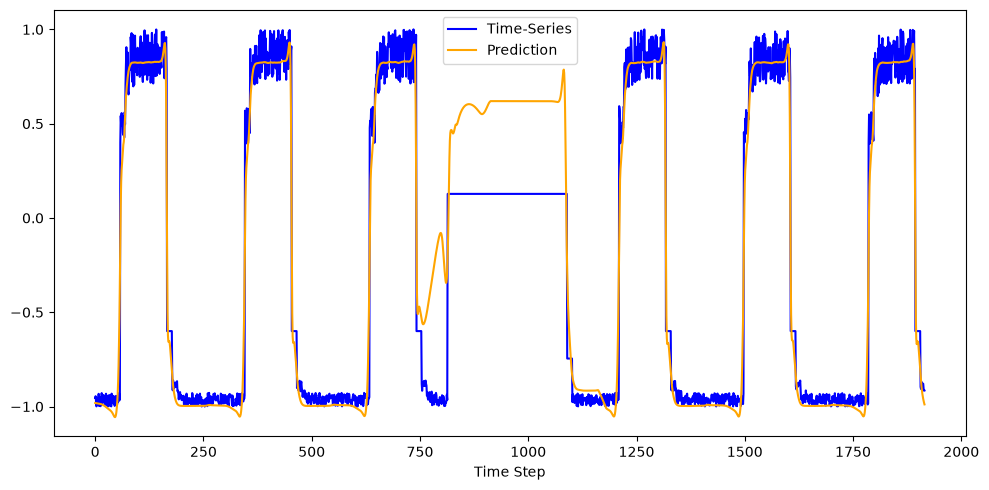

--------------
Art Signal 2
--------------
Epoch  25 | GG Loss: 0.056482 | GF Loss: -0.223720 | FC Loss: 0.631503 | DX Loss: -0.366880 | DZ Loss: -0.062173
Epoch  50 | GG Loss: 0.267638 | GF Loss: -1.028391 | FC Loss: 0.313201 | DX Loss: -0.179443 | DZ Loss: -11.696695
Epoch  75 | GG Loss: -2.819486 | GF Loss: -1.505775 | FC Loss: 0.077654 | DX Loss: 0.862293 | DZ Loss: -41.946491
Epoch 100 | GG Loss: -3.771834 | GF Loss: 1.000068 | FC Loss: 0.053113 | DX Loss: -0.031313 | DZ Loss: -64.243907
Epoch 125 | GG Loss: -2.591465 | GF Loss: 0.033599 | FC Loss: 0.045079 | DX Loss: -0.003875 | DZ Loss: -72.339967
Epoch 150 | GG Loss: -1.612439 | GF Loss: -0.404394 | FC Loss: 0.039341 | DX Loss: -0.273404 | DZ Loss: -76.646136
Epoch 175 | GG Loss: -1.555135 | GF Loss: -0.855077 | FC Loss: 0.037893 | DX Loss: -0.378336 | DZ Loss: -78.785385
Epoch 200 | GG Loss: -1.490173 | GF Loss: -0.390741 | FC Loss: 0.054784 | DX Loss: -1.279134 | DZ Loss: -79.917633
Epoch 225 | GG Loss: -2.337697 | GF Loss: -

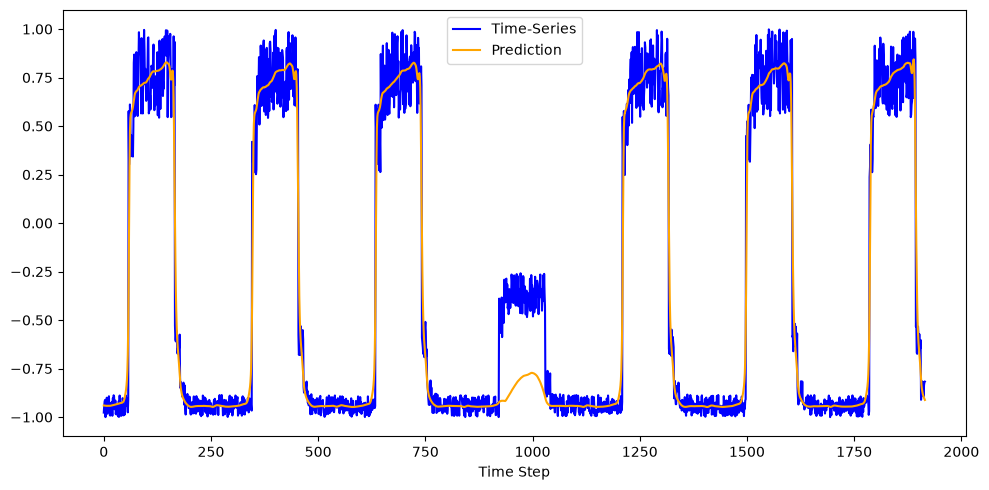

--------------
Art Signal 3
--------------
Epoch  25 | GG Loss: 0.271683 | GF Loss: 0.000746 | FC Loss: 0.631133 | DX Loss: 0.035344 | DZ Loss: -2.282134
Epoch  50 | GG Loss: -0.058833 | GF Loss: 0.044835 | FC Loss: 0.175000 | DX Loss: -0.049765 | DZ Loss: -24.053819
Epoch  75 | GG Loss: -2.514931 | GF Loss: -0.118768 | FC Loss: 0.050596 | DX Loss: -0.128184 | DZ Loss: -55.068132
Epoch 100 | GG Loss: -2.419941 | GF Loss: -1.716379 | FC Loss: 0.053914 | DX Loss: -1.389303 | DZ Loss: -68.965978
Epoch 125 | GG Loss: -0.996607 | GF Loss: 2.063564 | FC Loss: 0.045028 | DX Loss: -3.159589 | DZ Loss: -74.787648
Epoch 150 | GG Loss: -1.784835 | GF Loss: 0.059595 | FC Loss: 0.076236 | DX Loss: -4.462975 | DZ Loss: -77.244398
Epoch 175 | GG Loss: -0.092612 | GF Loss: 2.043968 | FC Loss: 0.039082 | DX Loss: -3.469648 | DZ Loss: -79.478141
Epoch 200 | GG Loss: -0.235653 | GF Loss: -0.336901 | FC Loss: 0.072649 | DX Loss: -1.858906 | DZ Loss: -80.363294
Epoch 225 | GG Loss: -0.086913 | GF Loss: 0.6

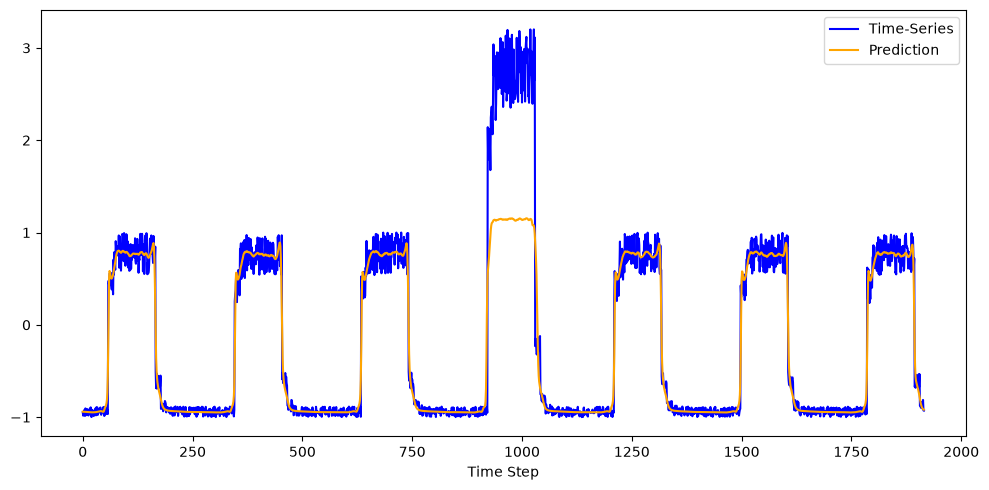

--------------
Art Signal 4
--------------
Epoch  25 | GG Loss: 1.094600 | GF Loss: 0.048068 | FC Loss: 0.631278 | DX Loss: -0.236198 | DZ Loss: -4.395843
Epoch  50 | GG Loss: 0.886166 | GF Loss: -0.776159 | FC Loss: 0.332420 | DX Loss: -0.607017 | DZ Loss: -29.351460
Epoch  75 | GG Loss: -1.966994 | GF Loss: -0.827861 | FC Loss: 0.115419 | DX Loss: -1.296137 | DZ Loss: -56.514255
Epoch 100 | GG Loss: -2.067511 | GF Loss: -3.157955 | FC Loss: 0.141341 | DX Loss: 0.106065 | DZ Loss: -68.647524
Epoch 125 | GG Loss: -1.714608 | GF Loss: -4.155221 | FC Loss: 0.170948 | DX Loss: 1.194628 | DZ Loss: -74.826871
Epoch 150 | GG Loss: -1.239208 | GF Loss: -1.480058 | FC Loss: 0.107595 | DX Loss: -1.366673 | DZ Loss: -77.785324
Epoch 175 | GG Loss: -0.856245 | GF Loss: -3.450815 | FC Loss: 0.138643 | DX Loss: 2.962052 | DZ Loss: -79.298397
Epoch 200 | GG Loss: -0.668288 | GF Loss: 0.907048 | FC Loss: 0.059395 | DX Loss: -0.751894 | DZ Loss: -80.048805
Epoch 225 | GG Loss: -1.208260 | GF Loss: 0.4

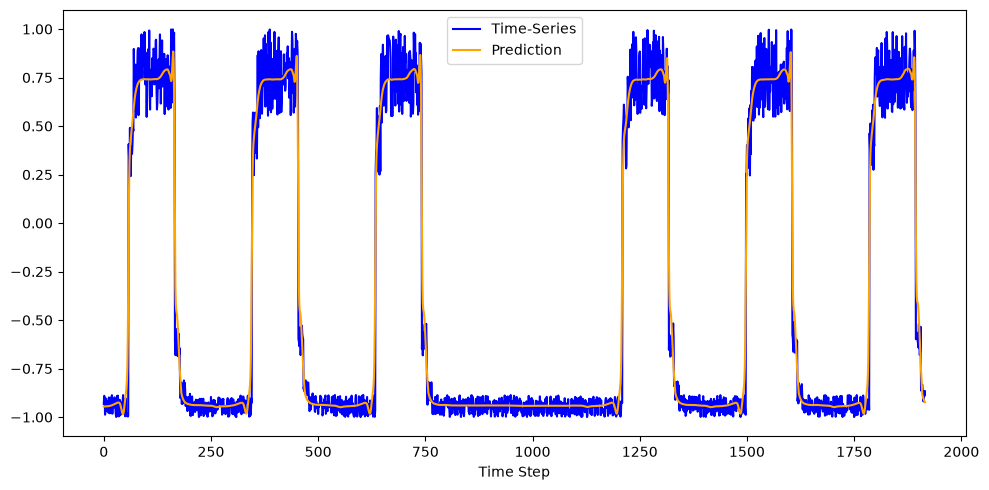

--------------
Art Signal 5
--------------
Epoch  25 | GG Loss: 0.880327 | GF Loss: -1.881369 | FC Loss: 0.095361 | DX Loss: -0.836319 | DZ Loss: -8.243951
Epoch  50 | GG Loss: 0.118320 | GF Loss: -1.083807 | FC Loss: 0.095662 | DX Loss: -0.101136 | DZ Loss: -39.120305
Epoch  75 | GG Loss: -1.783815 | GF Loss: 0.266044 | FC Loss: 0.090120 | DX Loss: -0.697103 | DZ Loss: -65.584421
Epoch 100 | GG Loss: -1.486023 | GF Loss: -0.380811 | FC Loss: 0.087091 | DX Loss: -0.779847 | DZ Loss: -75.492305
Epoch 125 | GG Loss: -0.218033 | GF Loss: -0.119593 | FC Loss: 0.083790 | DX Loss: -0.687870 | DZ Loss: -79.948244
Epoch 150 | GG Loss: -0.149038 | GF Loss: -0.182935 | FC Loss: 0.081316 | DX Loss: -0.529873 | DZ Loss: -81.574779
Epoch 175 | GG Loss: 0.023387 | GF Loss: -0.208647 | FC Loss: 0.080002 | DX Loss: -0.295742 | DZ Loss: -82.337737
Epoch 200 | GG Loss: 0.129260 | GF Loss: 0.750391 | FC Loss: 0.087939 | DX Loss: 0.154251 | DZ Loss: -82.344495
Epoch 225 | GG Loss: -0.138862 | GF Loss: 0.6

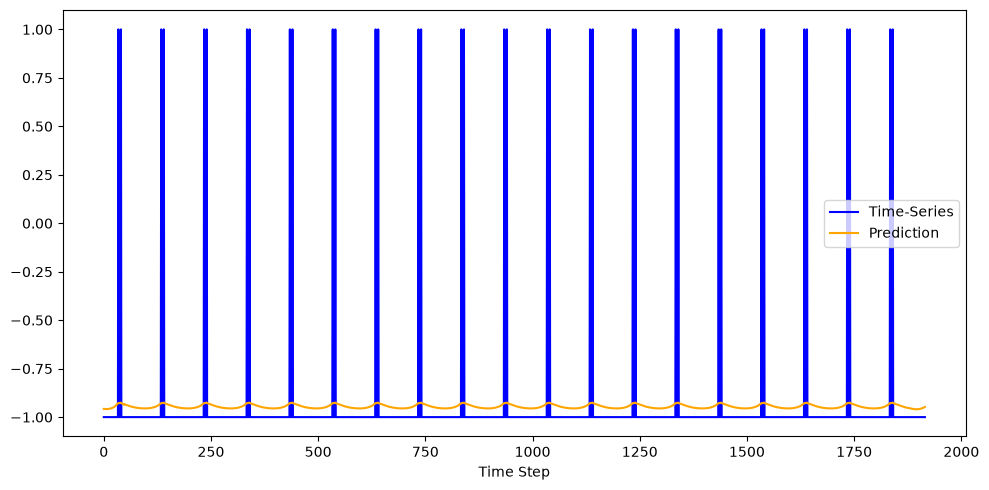

--------------
Art Signal 6
--------------
Epoch  25 | GG Loss: 1.293977 | GF Loss: -0.926748 | FC Loss: 0.052914 | DX Loss: -0.479096 | DZ Loss: -4.697933
Epoch  50 | GG Loss: -0.774447 | GF Loss: -3.396139 | FC Loss: 0.068815 | DX Loss: 0.269076 | DZ Loss: -27.499919
Epoch  75 | GG Loss: -4.439022 | GF Loss: -0.150890 | FC Loss: 0.049398 | DX Loss: -0.449573 | DZ Loss: -58.456181
Epoch 100 | GG Loss: -2.663137 | GF Loss: -0.385537 | FC Loss: 0.047235 | DX Loss: -0.540154 | DZ Loss: -72.904193
Epoch 125 | GG Loss: -2.134013 | GF Loss: -0.221978 | FC Loss: 0.045359 | DX Loss: -0.469655 | DZ Loss: -79.131103
Epoch 150 | GG Loss: -1.584916 | GF Loss: 0.338369 | FC Loss: 0.045552 | DX Loss: -0.353273 | DZ Loss: -81.597552
Epoch 175 | GG Loss: -1.583619 | GF Loss: 0.198687 | FC Loss: 0.045827 | DX Loss: -0.182877 | DZ Loss: -82.077890
Epoch 200 | GG Loss: -1.671379 | GF Loss: -0.117405 | FC Loss: 0.046478 | DX Loss: -0.048611 | DZ Loss: -82.395858
Epoch 225 | GG Loss: -1.318927 | GF Loss: 

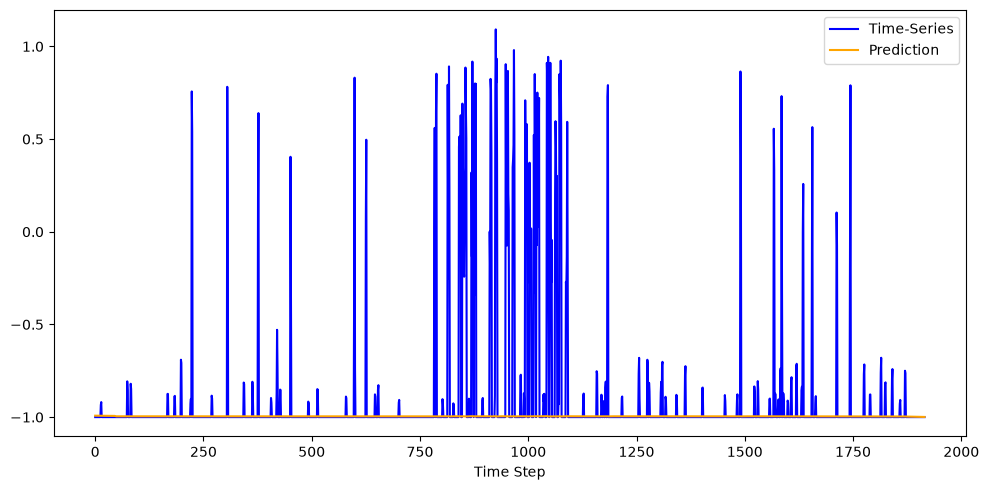

------------------
Art Signal Metrics
------------------
[point] Precision: 0.317 | Recall: 0.667 | F1: 0.389
[area] Precision: 0.181 | Recall: 0.667 | F1: 0.283


In [21]:
total_metrics = {name: np.zeros(3) for (name, _) in ART_HYPERPARAMS["rec_error_funcs"]}

for i, art_signal in enumerate(art_signals):
    X = art_signal["value"].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = art_signal["is_anomaly"].to_numpy()
    
    print("--------------")
    print(f"Art Signal {i + 1}")
    print("--------------")

    metrics = run_pipeline(X, y, **ART_HYPERPARAMS)

    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])

print("------------------")
print("Art Signal Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / len(art_signals)
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

### **Ad Exchange**

In [22]:
ad_ex_signals = nab_download_subdataset(folder=AD_EX_FOLDER, file_names=AD_EX_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading realAdExchange/!
---------------------
Total Signals: 6
Total Points: 9610
Total Anomaly Points: 960
Anomaly Rate: 9.99%


--------------
Ad Exchange Signal 1
--------------
Epoch  25 | GG Loss: 0.066182 | GF Loss: -0.105902 | FC Loss: 0.113838 | DX Loss: 1.778430 | DZ Loss: 1.947806
Epoch  50 | GG Loss: 0.074578 | GF Loss: -0.195679 | FC Loss: 0.092812 | DX Loss: -0.038906 | DZ Loss: 0.011835
Epoch  75 | GG Loss: 0.253118 | GF Loss: -0.336204 | FC Loss: 0.094149 | DX Loss: -0.050294 | DZ Loss: -0.416819
Epoch 100 | GG Loss: 1.747106 | GF Loss: -0.335048 | FC Loss: 0.095902 | DX Loss: 0.027279 | DZ Loss: -6.479389
Epoch 125 | GG Loss: 1.667402 | GF Loss: -0.038739 | FC Loss: 0.093289 | DX Loss: -0.040962 | DZ Loss: -17.094111
Epoch 150 | GG Loss: -0.379498 | GF Loss: 0.766883 | FC Loss: 0.090127 | DX Loss: -0.294763 | DZ Loss: -31.919815
Epoch 175 | GG Loss: -1.868877 | GF Loss: 1.391431 | FC Loss: 0.087854 | DX Loss: -0.693643 | DZ Loss: -49.050167
Epoch 200 | GG Loss: -2.354211 | GF Loss: 2.031735 | FC Loss: 0.082043 | DX Loss: -0.724744 | DZ Loss: -61.171956
Epoch 225 | GG Loss: -2.422207 | GF Loss: 0.8

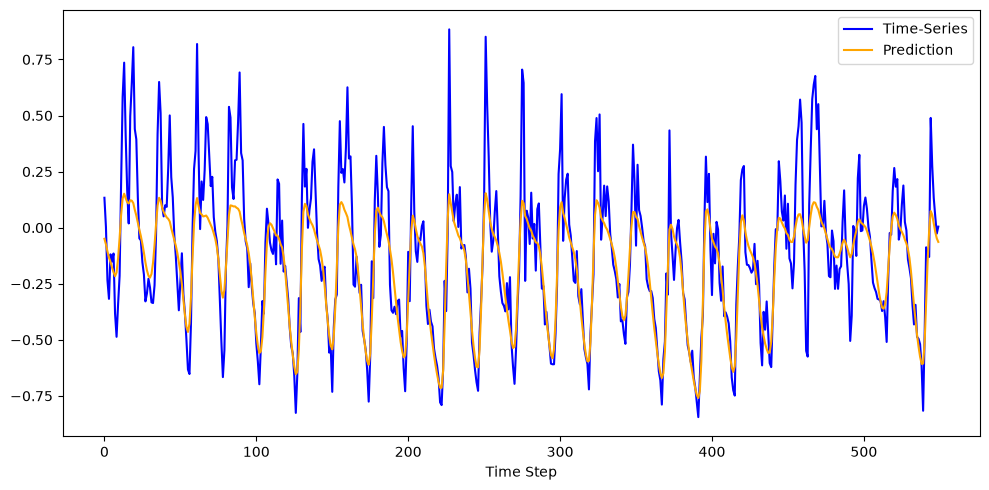

--------------
Ad Exchange Signal 2
--------------
Epoch  25 | GG Loss: 0.009461 | GF Loss: 0.051746 | FC Loss: 0.139921 | DX Loss: 1.552895 | DZ Loss: 1.611954
Epoch  50 | GG Loss: 0.241214 | GF Loss: 0.060902 | FC Loss: 0.134111 | DX Loss: 0.004950 | DZ Loss: -1.043921
Epoch  75 | GG Loss: 0.858870 | GF Loss: 0.074501 | FC Loss: 0.132952 | DX Loss: -0.006000 | DZ Loss: -6.946813
Epoch 100 | GG Loss: 0.264742 | GF Loss: 0.115693 | FC Loss: 0.131376 | DX Loss: -0.035450 | DZ Loss: -17.237958
Epoch 125 | GG Loss: -2.018337 | GF Loss: 0.174321 | FC Loss: 0.129075 | DX Loss: -0.151651 | DZ Loss: -31.151394
Epoch 150 | GG Loss: -4.341019 | GF Loss: 0.354900 | FC Loss: 0.122094 | DX Loss: -0.436454 | DZ Loss: -47.783539
Epoch 175 | GG Loss: -5.514865 | GF Loss: -0.043273 | FC Loss: 0.097375 | DX Loss: -0.465208 | DZ Loss: -60.022763
Epoch 200 | GG Loss: -4.960084 | GF Loss: -0.333355 | FC Loss: 0.058897 | DX Loss: 0.455132 | DZ Loss: -67.319877
Epoch 225 | GG Loss: -3.962192 | GF Loss: 2.14

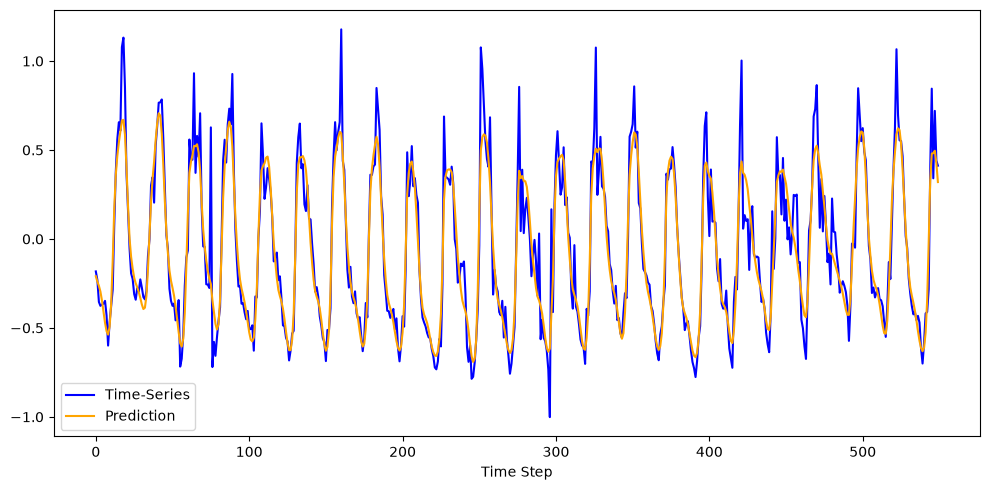

--------------
Ad Exchange Signal 3
--------------
Epoch  25 | GG Loss: -0.051344 | GF Loss: -0.021446 | FC Loss: 0.345403 | DX Loss: 1.872109 | DZ Loss: 2.067622
Epoch  50 | GG Loss: -0.016209 | GF Loss: -0.085700 | FC Loss: 0.039016 | DX Loss: -0.056686 | DZ Loss: -0.283901
Epoch  75 | GG Loss: 0.414757 | GF Loss: -0.462503 | FC Loss: 0.033538 | DX Loss: -0.323444 | DZ Loss: -3.826590
Epoch 100 | GG Loss: 0.886741 | GF Loss: -2.443647 | FC Loss: 0.040855 | DX Loss: -0.641210 | DZ Loss: -13.020107
Epoch 125 | GG Loss: -0.620783 | GF Loss: -3.238189 | FC Loss: 0.057616 | DX Loss: 0.376963 | DZ Loss: -24.723651
Epoch 150 | GG Loss: -3.546904 | GF Loss: -0.934854 | FC Loss: 0.036616 | DX Loss: 0.114320 | DZ Loss: -39.442917
Epoch 175 | GG Loss: -5.768358 | GF Loss: -0.115406 | FC Loss: 0.032819 | DX Loss: 0.001002 | DZ Loss: -54.118913
Epoch 200 | GG Loss: -6.583292 | GF Loss: 0.186915 | FC Loss: 0.032333 | DX Loss: -0.029729 | DZ Loss: -63.646418
Epoch 225 | GG Loss: -5.611031 | GF Loss

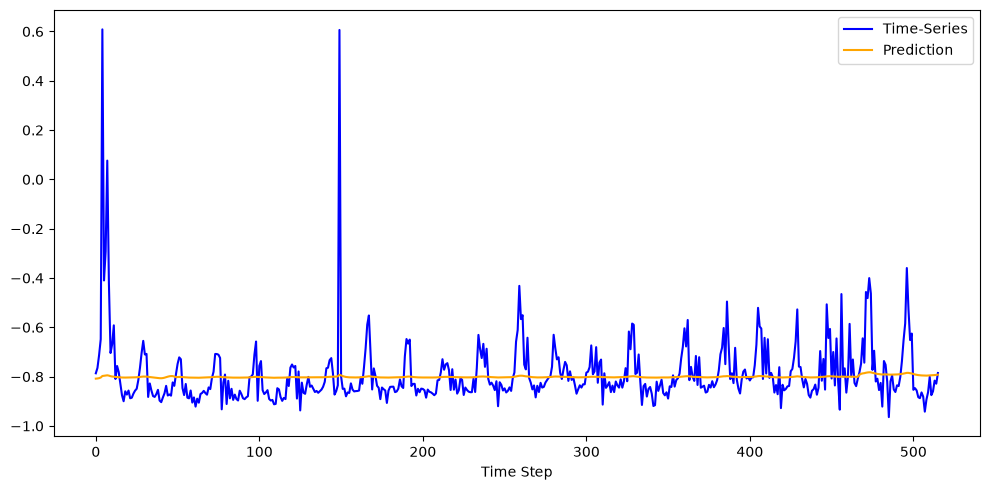

--------------
Ad Exchange Signal 4
--------------
Epoch  25 | GG Loss: -0.093060 | GF Loss: 0.317809 | FC Loss: 0.352348 | DX Loss: 0.918436 | DZ Loss: 2.350627
Epoch  50 | GG Loss: 0.065509 | GF Loss: -1.488765 | FC Loss: 0.049350 | DX Loss: -1.272730 | DZ Loss: -0.584032
Epoch  75 | GG Loss: 0.378900 | GF Loss: -3.424842 | FC Loss: 0.079959 | DX Loss: 0.132373 | DZ Loss: -4.668715
Epoch 100 | GG Loss: 0.194996 | GF Loss: -2.381296 | FC Loss: 0.068359 | DX Loss: 0.412806 | DZ Loss: -13.507066
Epoch 125 | GG Loss: -0.872731 | GF Loss: -0.703410 | FC Loss: 0.050760 | DX Loss: -0.089450 | DZ Loss: -25.835431
Epoch 150 | GG Loss: -3.066046 | GF Loss: 0.391000 | FC Loss: 0.045295 | DX Loss: -0.413138 | DZ Loss: -40.518117
Epoch 175 | GG Loss: -4.473539 | GF Loss: 0.607642 | FC Loss: 0.046341 | DX Loss: -0.433597 | DZ Loss: -53.602376
Epoch 200 | GG Loss: -4.363833 | GF Loss: 0.281701 | FC Loss: 0.044429 | DX Loss: -0.468053 | DZ Loss: -62.602421
Epoch 225 | GG Loss: -3.091760 | GF Loss: 0

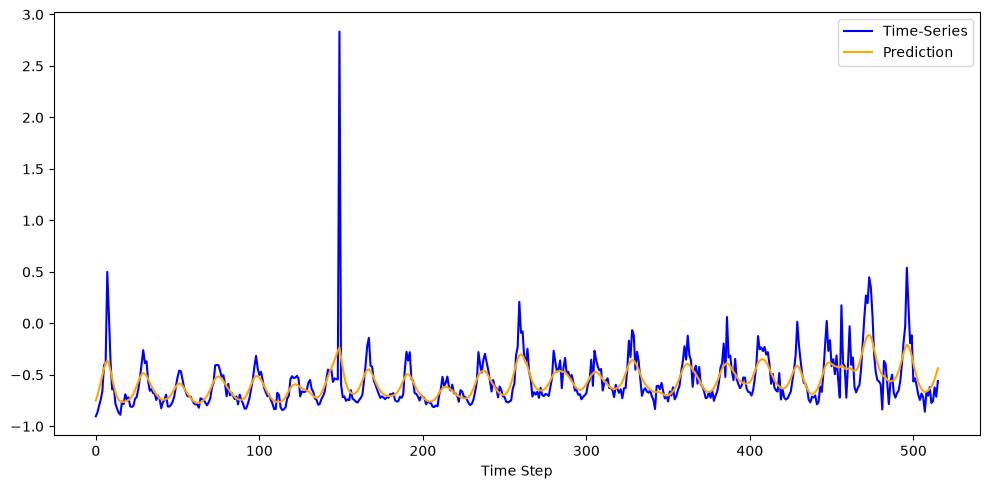

--------------
Ad Exchange Signal 5
--------------
Epoch  25 | GG Loss: 0.050875 | GF Loss: -0.623489 | FC Loss: 0.400954 | DX Loss: -0.157945 | DZ Loss: 1.901774
Epoch  50 | GG Loss: 0.078753 | GF Loss: -5.753992 | FC Loss: 0.031708 | DX Loss: -0.884536 | DZ Loss: -0.771129
Epoch  75 | GG Loss: 0.377656 | GF Loss: -6.814112 | FC Loss: 0.078477 | DX Loss: 1.380228 | DZ Loss: -6.373357
Epoch 100 | GG Loss: 0.759848 | GF Loss: -2.873340 | FC Loss: 0.032309 | DX Loss: 1.164529 | DZ Loss: -18.596006
Epoch 125 | GG Loss: -0.761627 | GF Loss: 0.671615 | FC Loss: 0.021853 | DX Loss: -0.420651 | DZ Loss: -33.037114
Epoch 150 | GG Loss: -3.566842 | GF Loss: 1.883912 | FC Loss: 0.031639 | DX Loss: -0.406058 | DZ Loss: -48.283484
Epoch 175 | GG Loss: -4.727058 | GF Loss: 1.277873 | FC Loss: 0.027706 | DX Loss: -0.274820 | DZ Loss: -60.590367
Epoch 200 | GG Loss: -4.552242 | GF Loss: -0.281210 | FC Loss: 0.019805 | DX Loss: -0.477339 | DZ Loss: -68.199658
Epoch 225 | GG Loss: -3.275116 | GF Loss: 

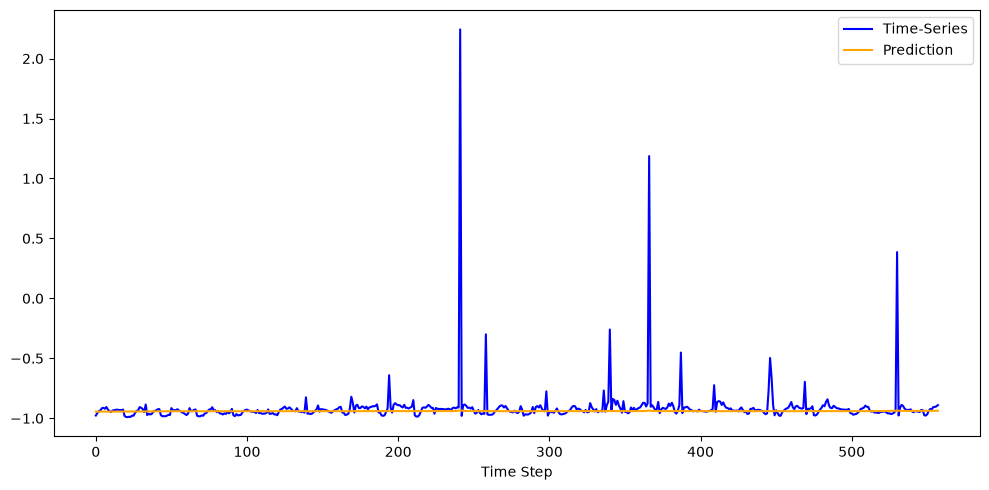

--------------
Ad Exchange Signal 6
--------------
Epoch  25 | GG Loss: -0.002255 | GF Loss: 0.340769 | FC Loss: 0.680369 | DX Loss: -0.343595 | DZ Loss: 0.926130
Epoch  50 | GG Loss: 0.146047 | GF Loss: -3.017959 | FC Loss: 0.031000 | DX Loss: -2.919786 | DZ Loss: -0.661820
Epoch  75 | GG Loss: 0.952390 | GF Loss: -6.382696 | FC Loss: 0.095279 | DX Loss: 0.542433 | DZ Loss: -6.249543
Epoch 100 | GG Loss: 0.756253 | GF Loss: -5.462850 | FC Loss: 0.086342 | DX Loss: 1.832983 | DZ Loss: -17.113810
Epoch 125 | GG Loss: -1.817364 | GF Loss: -0.903990 | FC Loss: 0.035286 | DX Loss: 0.254427 | DZ Loss: -30.717289
Epoch 150 | GG Loss: -4.922873 | GF Loss: 1.897420 | FC Loss: 0.044003 | DX Loss: -0.531970 | DZ Loss: -47.838424
Epoch 175 | GG Loss: -6.155658 | GF Loss: 0.766877 | FC Loss: 0.031254 | DX Loss: -0.488057 | DZ Loss: -60.865559
Epoch 200 | GG Loss: -6.339663 | GF Loss: -0.538751 | FC Loss: 0.028811 | DX Loss: -0.685081 | DZ Loss: -67.819785
Epoch 225 | GG Loss: -5.040341 | GF Loss: 

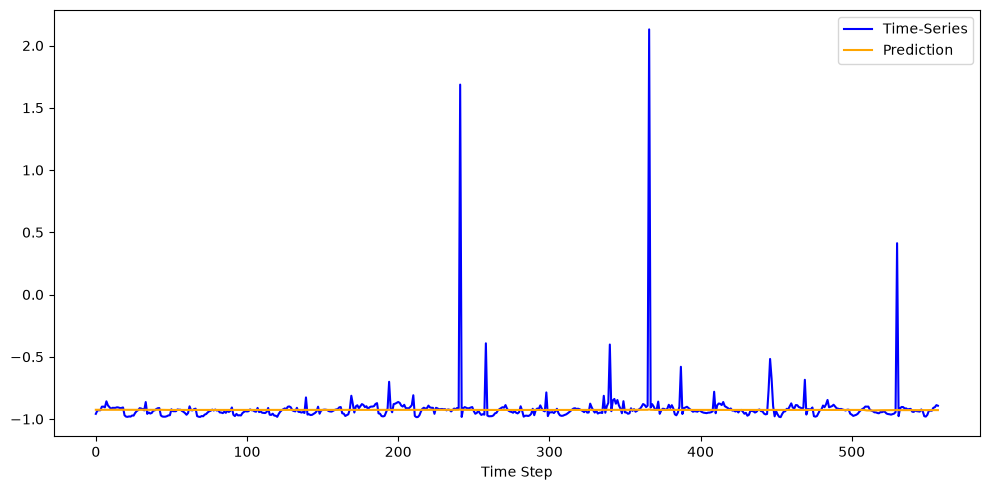

------------------
Ad Exchange Metrics
------------------
[point] Precision: 0.333 | Recall: 0.333 | F1: 0.333
[area] Precision: 0.333 | Recall: 0.333 | F1: 0.333


In [23]:
total_metrics = {name: np.zeros(3) for (name, _) in NAB_HYPERPARAMS["rec_error_funcs"]}

for i, ad_ex_signal in enumerate(ad_ex_signals):
    X = ad_ex_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    # min-max normalization to [-1, 1]
    y = ad_ex_signal['is_anomaly'].to_numpy()
    
    print("--------------")
    print(f"Ad Exchange Signal {i + 1}")
    print("--------------")

    metrics = run_pipeline(X, y, **NAB_HYPERPARAMS)

    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])

print("------------------")
print("Ad Exchange Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / len(ad_ex_signals)
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

### **AWS Cloudwatch**

In [24]:
aws_signals = nab_download_subdataset(folder=AWS_FOLDER, file_names=AWS_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.
Downloaded 10 .csv files.
Downloaded 15 .csv files.

Finished downloading realAWSCloudwatch/!
---------------------
Total Signals: 17
Total Points: 67740
Total Anomaly Points: 6312
Anomaly Rate: 9.32%


--------------
AWS Signal 1
--------------
Epoch  25 | GG Loss: 0.132800 | GF Loss: -7.927362 | FC Loss: 0.091662 | DX Loss: 0.245955 | DZ Loss: -3.127229
Epoch  50 | GG Loss: 1.265593 | GF Loss: 2.562314 | FC Loss: 0.045513 | DX Loss: -0.891504 | DZ Loss: -35.197280
Epoch  75 | GG Loss: -1.752943 | GF Loss: 0.445289 | FC Loss: 0.026939 | DX Loss: 0.026078 | DZ Loss: -63.723630
Epoch 100 | GG Loss: -2.680567 | GF Loss: -1.140277 | FC Loss: 0.024834 | DX Loss: -0.137496 | DZ Loss: -75.607631
Epoch 125 | GG Loss: -1.850696 | GF Loss: -0.610470 | FC Loss: 0.022090 | DX Loss: -0.482825 | DZ Loss: -80.122063
Epoch 150 | GG Loss: -0.645864 | GF Loss: -1.242509 | FC Loss: 0.019312 | DX Loss: -0.764671 | DZ Loss: -81.693441
Epoch 175 | GG Loss: -0.237623 | GF Loss: -0.177549 | FC Loss: 0.015896 | DX Loss: -0.681807 | DZ Loss: -82.337485
Epoch 200 | GG Loss: -0.180822 | GF Loss: -0.316011 | FC Loss: 0.041172 | DX Loss: 0.823491 | DZ Loss: -82.295112
Epoch 225 | GG Loss: -0.104197 | GF Loss: 2.8

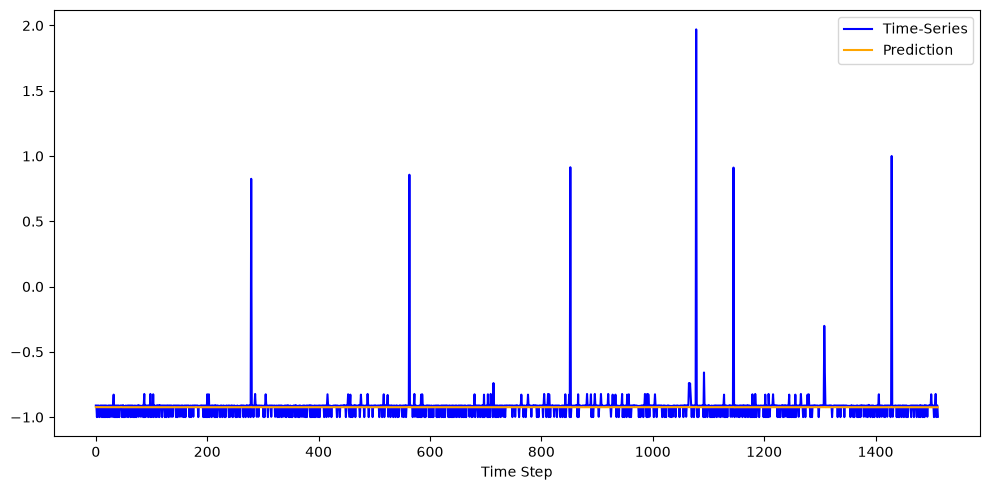

--------------
AWS Signal 2
--------------
Epoch  25 | GG Loss: -0.619304 | GF Loss: -2.115747 | FC Loss: 0.054087 | DX Loss: 0.035655 | DZ Loss: -2.683623
Epoch  50 | GG Loss: -1.245125 | GF Loss: 0.803562 | FC Loss: 0.045222 | DX Loss: -0.161024 | DZ Loss: -37.203531
Epoch  75 | GG Loss: -3.280646 | GF Loss: -0.250815 | FC Loss: 0.039335 | DX Loss: -0.295590 | DZ Loss: -64.872451
Epoch 100 | GG Loss: -3.292705 | GF Loss: -0.063376 | FC Loss: 0.038260 | DX Loss: -0.245761 | DZ Loss: -75.967674
Epoch 125 | GG Loss: -1.548509 | GF Loss: -0.327469 | FC Loss: 0.038359 | DX Loss: -0.042485 | DZ Loss: -80.567385
Epoch 150 | GG Loss: -1.233179 | GF Loss: -0.046037 | FC Loss: 0.039238 | DX Loss: -0.038837 | DZ Loss: -81.944981
Epoch 175 | GG Loss: -1.179252 | GF Loss: 0.424726 | FC Loss: 0.037134 | DX Loss: -0.108318 | DZ Loss: -82.340413
Epoch 200 | GG Loss: -1.189584 | GF Loss: 1.114294 | FC Loss: 0.036704 | DX Loss: -0.139442 | DZ Loss: -82.519255
Epoch 225 | GG Loss: -1.708160 | GF Loss: 

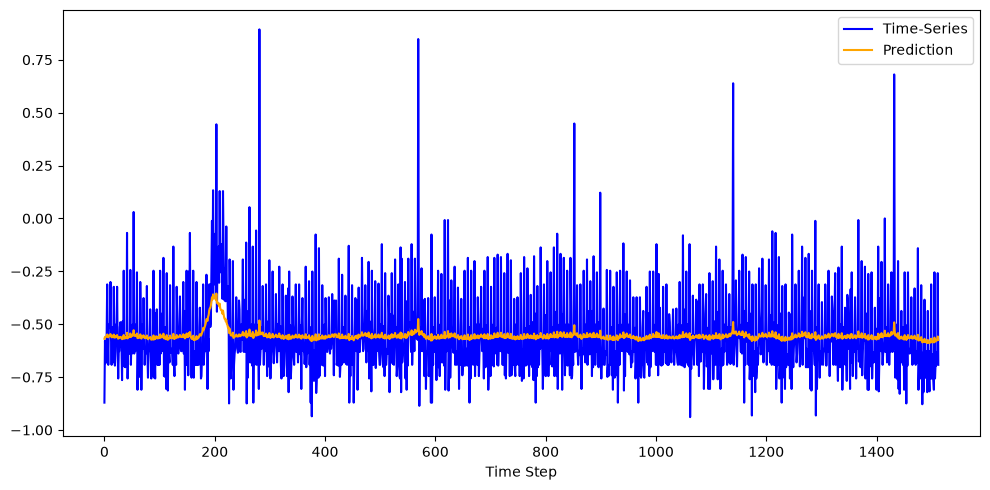

--------------
AWS Signal 3
--------------
Epoch  25 | GG Loss: 1.118001 | GF Loss: -0.083135 | FC Loss: 0.097249 | DX Loss: -0.041410 | DZ Loss: -6.935308
Epoch  50 | GG Loss: -0.450665 | GF Loss: -0.807546 | FC Loss: 0.103121 | DX Loss: 0.007852 | DZ Loss: -44.993380
Epoch  75 | GG Loss: -1.683698 | GF Loss: -0.321061 | FC Loss: 0.097398 | DX Loss: -0.079346 | DZ Loss: -68.937947
Epoch 100 | GG Loss: -0.037671 | GF Loss: 0.205151 | FC Loss: 0.099005 | DX Loss: -0.234833 | DZ Loss: -78.408160
Epoch 125 | GG Loss: -0.029630 | GF Loss: -0.052275 | FC Loss: 0.096541 | DX Loss: -0.238693 | DZ Loss: -81.450817
Epoch 150 | GG Loss: -0.168203 | GF Loss: -0.219004 | FC Loss: 0.095875 | DX Loss: -0.206884 | DZ Loss: -82.140018
Epoch 175 | GG Loss: -0.264133 | GF Loss: -0.366056 | FC Loss: 0.095351 | DX Loss: -0.144547 | DZ Loss: -82.229159
Epoch 200 | GG Loss: -0.410866 | GF Loss: -0.549801 | FC Loss: 0.095018 | DX Loss: -0.088165 | DZ Loss: -82.116689
Epoch 225 | GG Loss: -0.519711 | GF Loss:

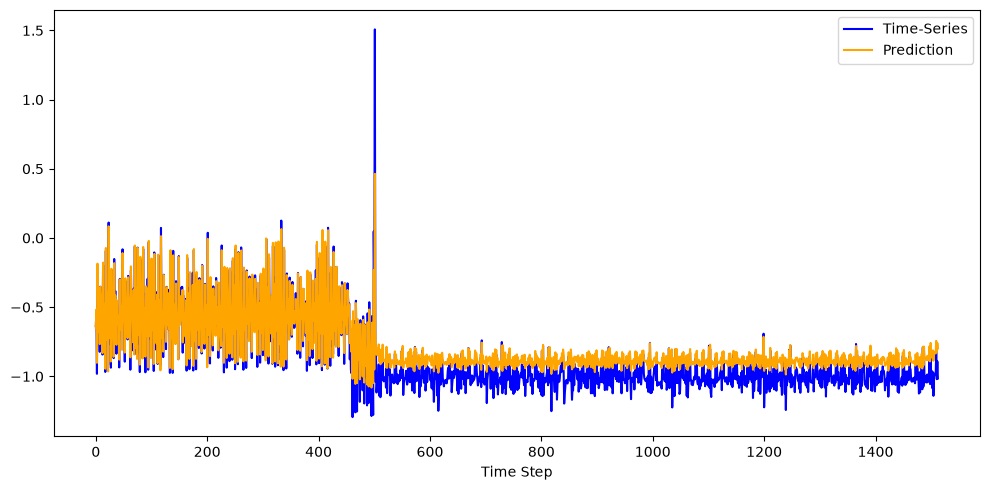

--------------
AWS Signal 4
--------------
Epoch  25 | GG Loss: 0.510913 | GF Loss: -6.108997 | FC Loss: 0.322316 | DX Loss: -0.807354 | DZ Loss: -4.676883
Epoch  50 | GG Loss: -1.386401 | GF Loss: -2.107026 | FC Loss: 0.318670 | DX Loss: 0.186066 | DZ Loss: -39.067315
Epoch  75 | GG Loss: -4.826095 | GF Loss: 0.472731 | FC Loss: 0.283787 | DX Loss: -0.542873 | DZ Loss: -65.285989
Epoch 100 | GG Loss: -3.377046 | GF Loss: -0.210044 | FC Loss: 0.265724 | DX Loss: -0.621173 | DZ Loss: -75.600834
Epoch 125 | GG Loss: -3.215120 | GF Loss: 0.441137 | FC Loss: 0.246218 | DX Loss: -0.557835 | DZ Loss: -79.172477
Epoch 150 | GG Loss: -2.328125 | GF Loss: 0.021832 | FC Loss: 0.206145 | DX Loss: -0.488806 | DZ Loss: -80.357684
Epoch 175 | GG Loss: -2.209837 | GF Loss: 0.306672 | FC Loss: 0.153332 | DX Loss: -0.296102 | DZ Loss: -81.103636
Epoch 200 | GG Loss: -1.823254 | GF Loss: -0.424798 | FC Loss: 0.112156 | DX Loss: -0.104642 | DZ Loss: -81.464718
Epoch 225 | GG Loss: -1.852832 | GF Loss: -0

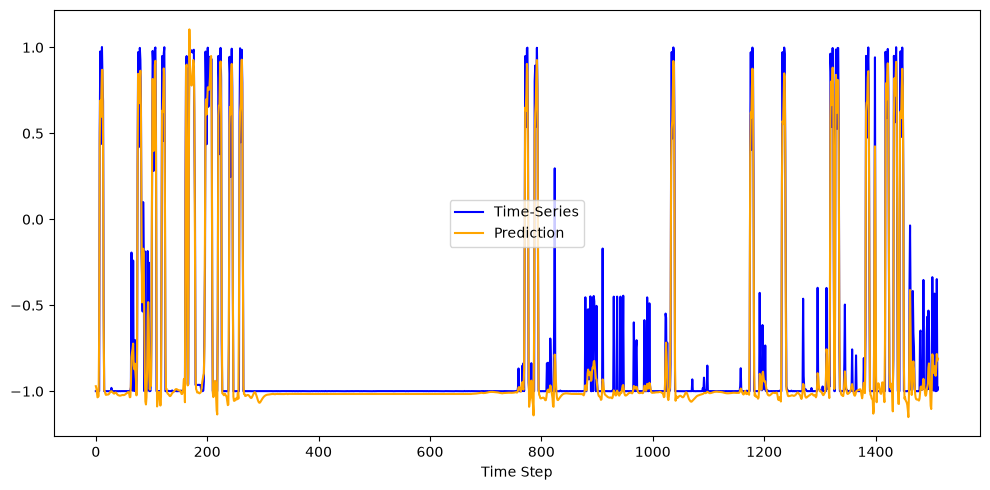

--------------
AWS Signal 5
--------------
Epoch  25 | GG Loss: -0.114203 | GF Loss: -4.892794 | FC Loss: 0.185599 | DX Loss: -0.210246 | DZ Loss: -2.124186
Epoch  50 | GG Loss: 0.134488 | GF Loss: -0.799030 | FC Loss: 0.159412 | DX Loss: -0.111982 | DZ Loss: -35.379124
Epoch  75 | GG Loss: -2.680670 | GF Loss: 0.654261 | FC Loss: 0.137047 | DX Loss: -0.388452 | DZ Loss: -63.256697
Epoch 100 | GG Loss: -2.990177 | GF Loss: -0.632002 | FC Loss: 0.122787 | DX Loss: -0.535634 | DZ Loss: -74.205708
Epoch 125 | GG Loss: -1.564405 | GF Loss: -0.047536 | FC Loss: 0.110811 | DX Loss: -0.571082 | DZ Loss: -78.918746
Epoch 150 | GG Loss: -0.431871 | GF Loss: -0.131017 | FC Loss: 0.093127 | DX Loss: -0.568393 | DZ Loss: -80.797692
Epoch 175 | GG Loss: -0.232538 | GF Loss: -0.672316 | FC Loss: 0.074063 | DX Loss: -0.564311 | DZ Loss: -81.583011
Epoch 200 | GG Loss: -0.419027 | GF Loss: 0.057505 | FC Loss: 0.053998 | DX Loss: -0.534347 | DZ Loss: -81.823078
Epoch 225 | GG Loss: -0.166221 | GF Loss:

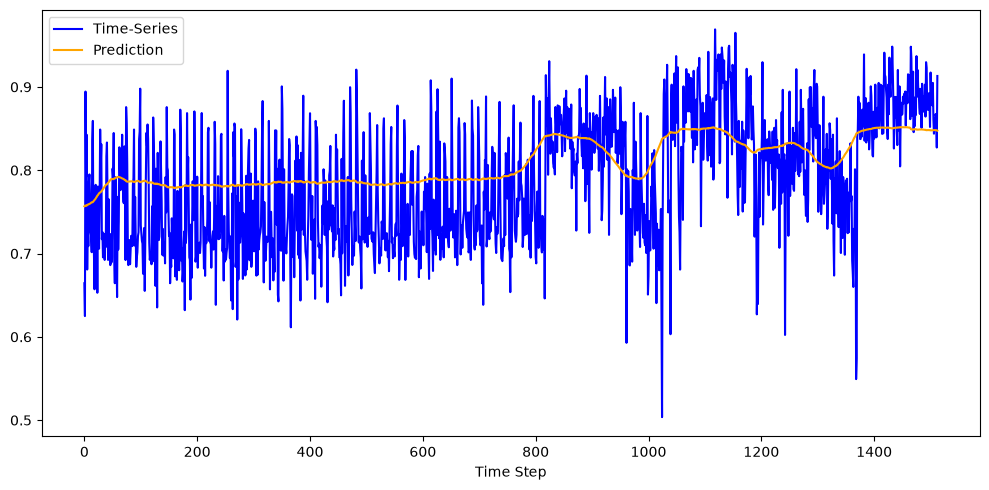

--------------
AWS Signal 6
--------------
Epoch  25 | GG Loss: 0.703817 | GF Loss: -0.270714 | FC Loss: 0.108055 | DX Loss: -0.024417 | DZ Loss: -5.138596
Epoch  50 | GG Loss: -2.440733 | GF Loss: -0.593384 | FC Loss: 0.106477 | DX Loss: -0.019130 | DZ Loss: -40.475077
Epoch  75 | GG Loss: -4.077954 | GF Loss: -1.164989 | FC Loss: 0.101674 | DX Loss: -0.155548 | DZ Loss: -65.232701
Epoch 100 | GG Loss: -2.481013 | GF Loss: -1.854047 | FC Loss: 0.091013 | DX Loss: -0.347583 | DZ Loss: -74.555746
Epoch 125 | GG Loss: -1.595050 | GF Loss: -2.931445 | FC Loss: 0.049191 | DX Loss: -0.211523 | DZ Loss: -78.814746
Epoch 150 | GG Loss: -1.088349 | GF Loss: -1.938649 | FC Loss: 0.021740 | DX Loss: 0.612078 | DZ Loss: -80.965587
Epoch 175 | GG Loss: -0.954024 | GF Loss: -0.615005 | FC Loss: 0.012855 | DX Loss: -1.222457 | DZ Loss: -81.767494
Epoch 200 | GG Loss: -0.966818 | GF Loss: -2.040303 | FC Loss: 0.043857 | DX Loss: -0.316077 | DZ Loss: -82.038699
Epoch 225 | GG Loss: -0.884884 | GF Loss

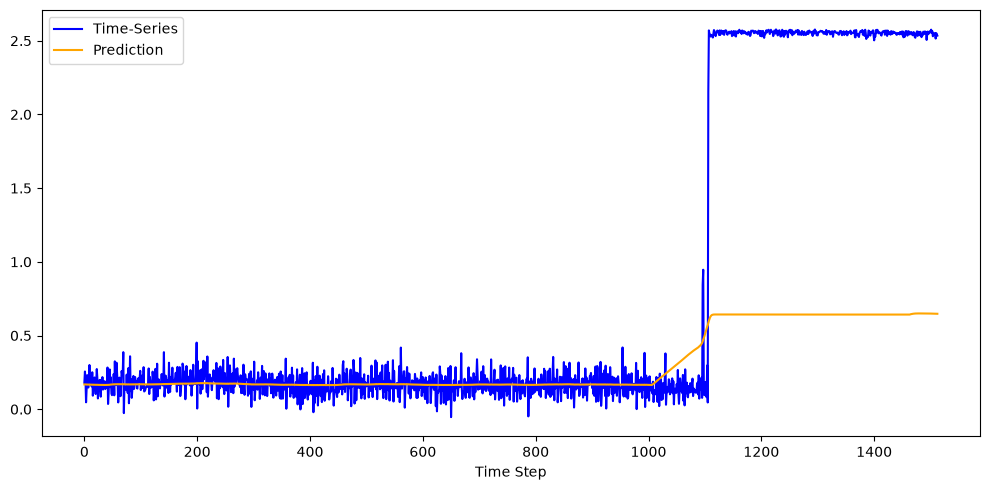

--------------
AWS Signal 7
--------------
Epoch  25 | GG Loss: 0.221151 | GF Loss: -3.366551 | FC Loss: 0.047847 | DX Loss: -1.461295 | DZ Loss: -7.085842
Epoch  50 | GG Loss: -1.468466 | GF Loss: -0.233109 | FC Loss: 0.028365 | DX Loss: -0.207086 | DZ Loss: -44.440141
Epoch  75 | GG Loss: -2.790816 | GF Loss: -0.079175 | FC Loss: 0.023720 | DX Loss: -0.883642 | DZ Loss: -68.292983
Epoch 100 | GG Loss: -1.369595 | GF Loss: 0.086699 | FC Loss: 0.019605 | DX Loss: -0.764195 | DZ Loss: -77.982088
Epoch 125 | GG Loss: -0.278133 | GF Loss: 0.059342 | FC Loss: 0.016871 | DX Loss: -0.608459 | DZ Loss: -81.649812
Epoch 150 | GG Loss: -0.278551 | GF Loss: 0.094804 | FC Loss: 0.014837 | DX Loss: -0.381458 | DZ Loss: -82.592047
Epoch 175 | GG Loss: -0.226158 | GF Loss: -0.190649 | FC Loss: 0.019642 | DX Loss: 0.146161 | DZ Loss: -82.897123
Epoch 200 | GG Loss: -0.189417 | GF Loss: 0.237444 | FC Loss: 0.013625 | DX Loss: 0.057848 | DZ Loss: -83.072512
Epoch 225 | GG Loss: -0.480152 | GF Loss: 0.0

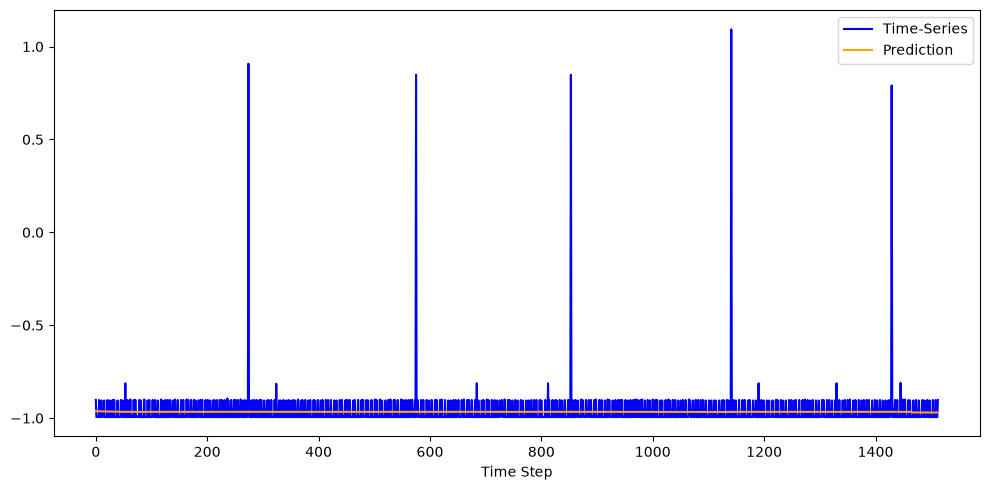

--------------
AWS Signal 8
--------------
Epoch  25 | GG Loss: 0.477523 | GF Loss: -0.564969 | FC Loss: 0.073249 | DX Loss: -0.297158 | DZ Loss: -5.045619
Epoch  50 | GG Loss: -1.375866 | GF Loss: -1.913740 | FC Loss: 0.079664 | DX Loss: -0.118457 | DZ Loss: -40.936996
Epoch  75 | GG Loss: -3.948667 | GF Loss: -0.193837 | FC Loss: 0.069574 | DX Loss: -0.745463 | DZ Loss: -65.858596
Epoch 100 | GG Loss: -3.080325 | GF Loss: -0.395327 | FC Loss: 0.066367 | DX Loss: -0.749926 | DZ Loss: -75.904944
Epoch 125 | GG Loss: -1.557975 | GF Loss: -0.436913 | FC Loss: 0.062459 | DX Loss: -0.638559 | DZ Loss: -80.249031
Epoch 150 | GG Loss: -0.600963 | GF Loss: -0.160623 | FC Loss: 0.058921 | DX Loss: -0.491949 | DZ Loss: -81.693903
Epoch 175 | GG Loss: -0.802852 | GF Loss: -0.057997 | FC Loss: 0.055846 | DX Loss: -0.361185 | DZ Loss: -82.000422
Epoch 200 | GG Loss: -0.699689 | GF Loss: -0.276993 | FC Loss: 0.052254 | DX Loss: -0.275991 | DZ Loss: -82.111518
Epoch 225 | GG Loss: -0.624520 | GF Los

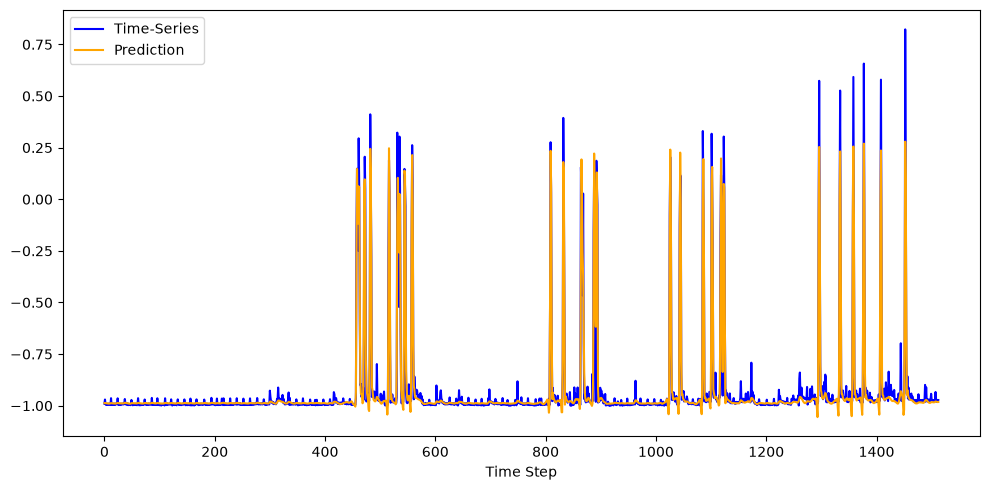

--------------
AWS Signal 9
--------------
Epoch  25 | GG Loss: 1.251736 | GF Loss: -4.579197 | FC Loss: 0.045071 | DX Loss: -0.807316 | DZ Loss: -6.862098
Epoch  50 | GG Loss: -0.417195 | GF Loss: 1.877425 | FC Loss: 0.034596 | DX Loss: -0.438898 | DZ Loss: -48.544808
Epoch  75 | GG Loss: -2.284742 | GF Loss: -1.011404 | FC Loss: 0.025783 | DX Loss: -0.727506 | DZ Loss: -71.099180
Epoch 100 | GG Loss: -0.650716 | GF Loss: -0.055549 | FC Loss: 0.020835 | DX Loss: -0.614884 | DZ Loss: -79.405497
Epoch 125 | GG Loss: -0.617814 | GF Loss: 0.232020 | FC Loss: 0.019380 | DX Loss: -0.399223 | DZ Loss: -81.347053
Epoch 150 | GG Loss: -0.376155 | GF Loss: -1.231872 | FC Loss: 0.028502 | DX Loss: 0.501082 | DZ Loss: -81.642809
Epoch 175 | GG Loss: 0.234918 | GF Loss: 0.503382 | FC Loss: 0.018040 | DX Loss: -0.074882 | DZ Loss: -82.124704
Epoch 200 | GG Loss: 0.364204 | GF Loss: 0.401011 | FC Loss: 0.016472 | DX Loss: 0.008105 | DZ Loss: -82.461084
Epoch 225 | GG Loss: 0.208288 | GF Loss: 1.0955

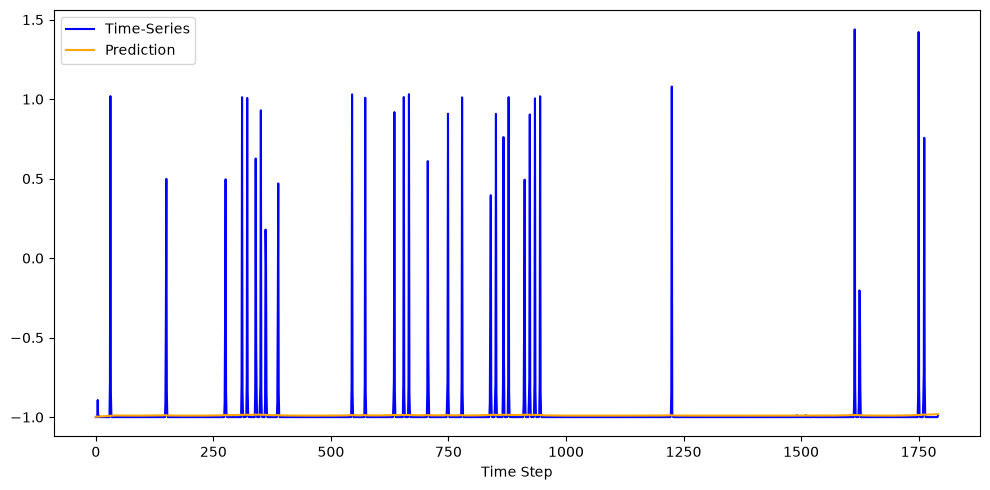

--------------
AWS Signal 10
--------------
Epoch  25 | GG Loss: 1.032765 | GF Loss: -5.451634 | FC Loss: 0.079972 | DX Loss: 0.020311 | DZ Loss: -11.000655
Epoch  50 | GG Loss: -2.404780 | GF Loss: 1.031403 | FC Loss: 0.042621 | DX Loss: -0.385909 | DZ Loss: -50.523014
Epoch  75 | GG Loss: -4.870904 | GF Loss: -0.862857 | FC Loss: 0.040315 | DX Loss: -0.447789 | DZ Loss: -70.773174
Epoch 100 | GG Loss: -2.337900 | GF Loss: 0.035134 | FC Loss: 0.037308 | DX Loss: -0.500269 | DZ Loss: -78.550545
Epoch 125 | GG Loss: -0.789297 | GF Loss: -0.095583 | FC Loss: 0.035458 | DX Loss: -0.455120 | DZ Loss: -81.312567
Epoch 150 | GG Loss: -0.540743 | GF Loss: 0.084482 | FC Loss: 0.034211 | DX Loss: -0.339932 | DZ Loss: -82.219119
Epoch 175 | GG Loss: -0.538554 | GF Loss: -0.469990 | FC Loss: 0.035151 | DX Loss: 0.117481 | DZ Loss: -82.541191
Epoch 200 | GG Loss: -0.462931 | GF Loss: 0.474962 | FC Loss: 0.031837 | DX Loss: 0.017703 | DZ Loss: -82.765262
Epoch 225 | GG Loss: -0.511126 | GF Loss: 0.

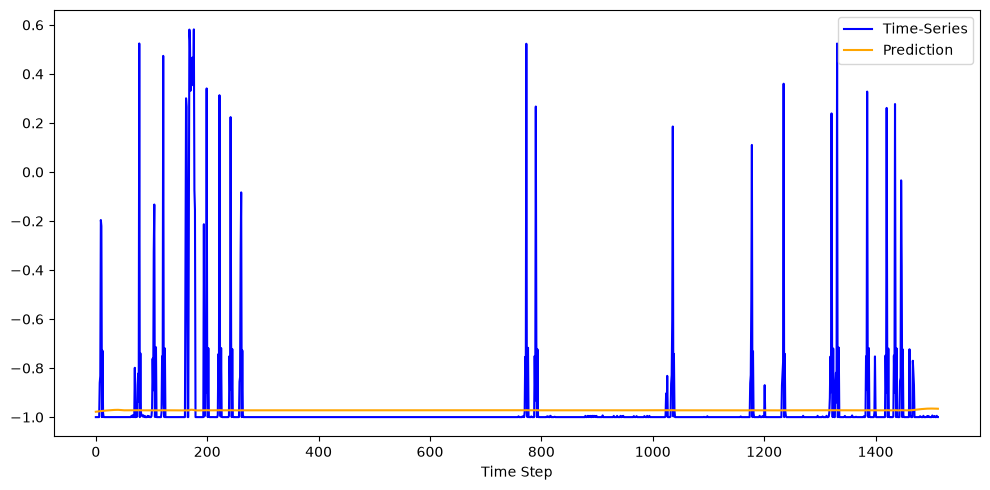

--------------
AWS Signal 11
--------------
Epoch  25 | GG Loss: 0.953510 | GF Loss: -7.489025 | FC Loss: 0.066269 | DX Loss: -1.354695 | DZ Loss: -5.827211
Epoch  50 | GG Loss: -0.477187 | GF Loss: 1.116283 | FC Loss: 0.018487 | DX Loss: -1.026447 | DZ Loss: -42.031715
Epoch  75 | GG Loss: -2.267514 | GF Loss: 0.049065 | FC Loss: 0.014346 | DX Loss: -0.889252 | DZ Loss: -67.951261
Epoch 100 | GG Loss: -0.319617 | GF Loss: 0.143494 | FC Loss: 0.011077 | DX Loss: -0.856886 | DZ Loss: -78.411440
Epoch 125 | GG Loss: 0.382361 | GF Loss: 0.051010 | FC Loss: 0.007770 | DX Loss: -0.702298 | DZ Loss: -81.927177
Epoch 150 | GG Loss: 0.415683 | GF Loss: 0.055475 | FC Loss: 0.004556 | DX Loss: -0.311752 | DZ Loss: -83.047684
Epoch 175 | GG Loss: 0.382930 | GF Loss: 0.060216 | FC Loss: 0.005653 | DX Loss: -0.031465 | DZ Loss: -83.470709
Epoch 200 | GG Loss: 0.384175 | GF Loss: 0.214527 | FC Loss: 0.003367 | DX Loss: 0.053085 | DZ Loss: -83.727718
Epoch 225 | GG Loss: 0.390374 | GF Loss: 0.070395 

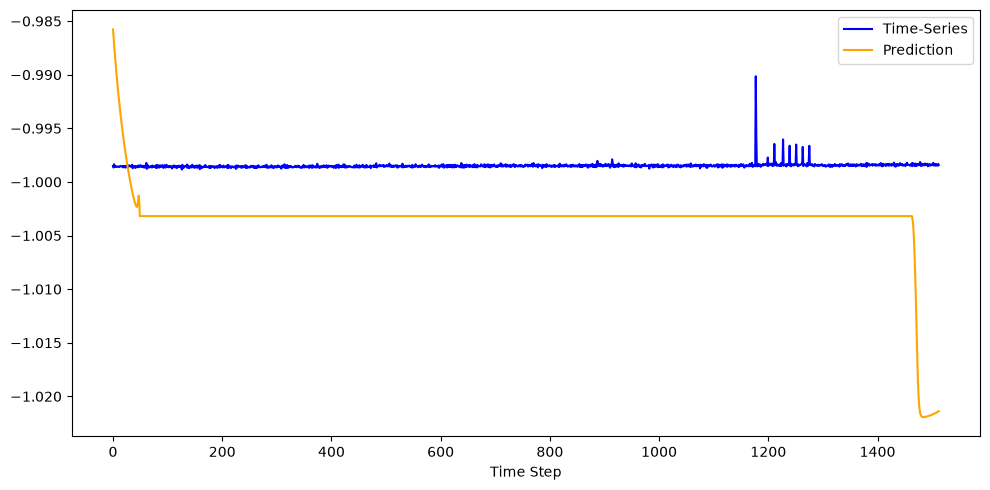

--------------
AWS Signal 12
--------------
Epoch  25 | GG Loss: 0.251131 | GF Loss: -5.518616 | FC Loss: 0.110679 | DX Loss: -0.407688 | DZ Loss: -6.475004
Epoch  50 | GG Loss: -6.091706 | GF Loss: 0.112433 | FC Loss: 0.063970 | DX Loss: -0.818612 | DZ Loss: -48.372642
Epoch  75 | GG Loss: -4.288705 | GF Loss: -0.277716 | FC Loss: 0.060392 | DX Loss: -0.867992 | DZ Loss: -71.855548
Epoch 100 | GG Loss: -2.104829 | GF Loss: 0.021432 | FC Loss: 0.057681 | DX Loss: -0.747265 | DZ Loss: -78.820097
Epoch 125 | GG Loss: -1.504805 | GF Loss: 0.007172 | FC Loss: 0.055061 | DX Loss: -0.567636 | DZ Loss: -81.470805
Epoch 150 | GG Loss: -1.517719 | GF Loss: -0.200757 | FC Loss: 0.052480 | DX Loss: -0.350573 | DZ Loss: -82.090592
Epoch 175 | GG Loss: -1.793740 | GF Loss: -0.155555 | FC Loss: 0.053235 | DX Loss: -0.004609 | DZ Loss: -82.103328
Epoch 200 | GG Loss: -1.396381 | GF Loss: 1.474148 | FC Loss: 0.055251 | DX Loss: -0.141620 | DZ Loss: -82.421338
Epoch 225 | GG Loss: -1.467920 | GF Loss: 

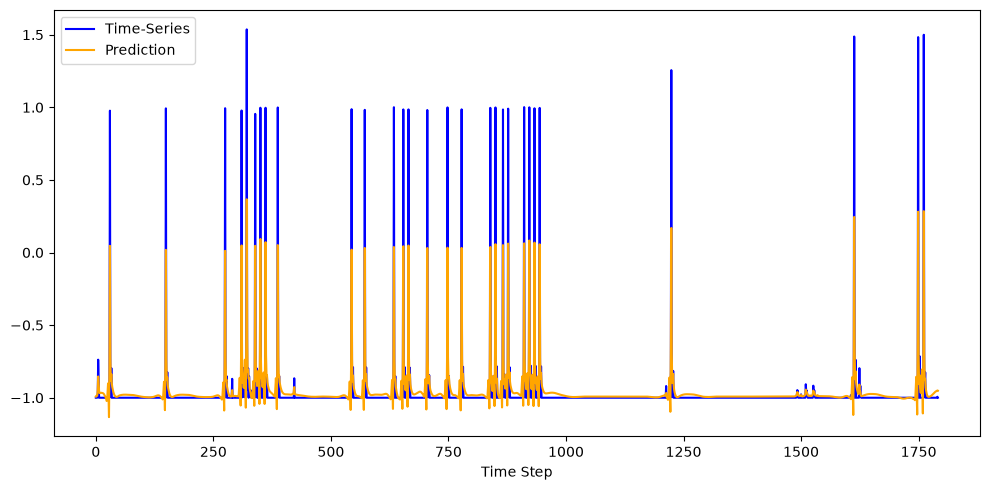

--------------
AWS Signal 13
--------------
Epoch  25 | GG Loss: 1.003698 | GF Loss: -1.466934 | FC Loss: 0.105027 | DX Loss: -0.880448 | DZ Loss: -3.295277
Epoch  50 | GG Loss: -1.877742 | GF Loss: -0.192752 | FC Loss: 0.097445 | DX Loss: -0.193867 | DZ Loss: -34.488045
Epoch  75 | GG Loss: -4.613374 | GF Loss: -0.144098 | FC Loss: 0.095133 | DX Loss: -0.323769 | DZ Loss: -65.911667
Epoch 100 | GG Loss: -2.186748 | GF Loss: -0.198902 | FC Loss: 0.093836 | DX Loss: -0.330039 | DZ Loss: -75.857600
Epoch 125 | GG Loss: -0.946873 | GF Loss: -0.151577 | FC Loss: 0.091975 | DX Loss: -0.266158 | DZ Loss: -80.143002
Epoch 150 | GG Loss: -1.571585 | GF Loss: -0.269177 | FC Loss: 0.089814 | DX Loss: -0.131028 | DZ Loss: -81.102475
Epoch 175 | GG Loss: -1.482914 | GF Loss: -0.435230 | FC Loss: 0.089875 | DX Loss: 0.199981 | DZ Loss: -81.386667
Epoch 200 | GG Loss: -1.439473 | GF Loss: 0.285066 | FC Loss: 0.085218 | DX Loss: -0.190072 | DZ Loss: -81.458925
Epoch 225 | GG Loss: -1.214515 | GF Loss

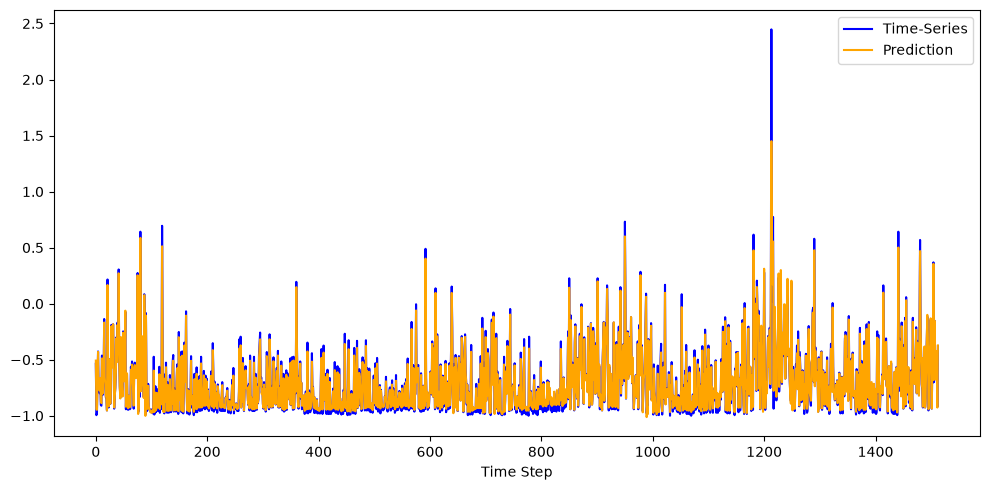

--------------
AWS Signal 14
--------------
Epoch  25 | GG Loss: 0.592506 | GF Loss: -0.956684 | FC Loss: 0.011852 | DX Loss: 0.090340 | DZ Loss: -5.629918
Epoch  50 | GG Loss: -2.174139 | GF Loss: 0.031169 | FC Loss: 0.008102 | DX Loss: -0.065587 | DZ Loss: -47.296339
Epoch  75 | GG Loss: -1.296834 | GF Loss: -0.177814 | FC Loss: 0.007330 | DX Loss: -0.146277 | DZ Loss: -72.895218
Epoch 100 | GG Loss: -0.649682 | GF Loss: -0.292345 | FC Loss: 0.007303 | DX Loss: -0.015851 | DZ Loss: -80.433132
Epoch 125 | GG Loss: -0.700676 | GF Loss: -0.294344 | FC Loss: 0.008845 | DX Loss: 0.070525 | DZ Loss: -82.561797
Epoch 150 | GG Loss: -0.672468 | GF Loss: 0.037789 | FC Loss: 0.007877 | DX Loss: -0.045270 | DZ Loss: -83.104543
Epoch 175 | GG Loss: -0.670237 | GF Loss: 0.067464 | FC Loss: 0.007162 | DX Loss: 0.045186 | DZ Loss: -83.330625
Epoch 200 | GG Loss: -0.709715 | GF Loss: -0.037346 | FC Loss: 0.007480 | DX Loss: -0.010872 | DZ Loss: -83.478383
Epoch 225 | GG Loss: -0.747534 | GF Loss: -0

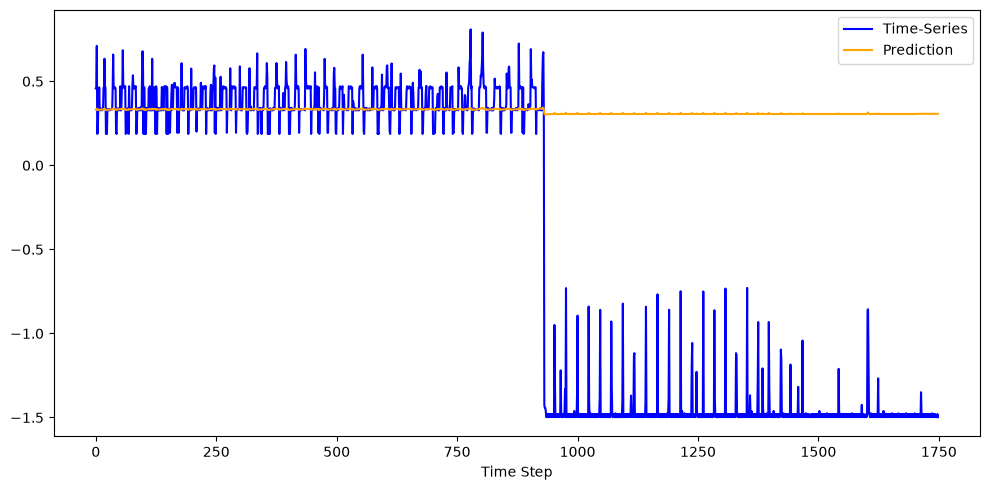

--------------
AWS Signal 15
--------------
Epoch  25 | GG Loss: -0.353095 | GF Loss: -0.684950 | FC Loss: 0.507511 | DX Loss: -0.389898 | DZ Loss: 2.156578
Epoch  50 | GG Loss: -0.862986 | GF Loss: -3.863393 | FC Loss: 0.095232 | DX Loss: -2.545543 | DZ Loss: -2.514031
Epoch  75 | GG Loss: -0.551494 | GF Loss: -6.877598 | FC Loss: 0.067286 | DX Loss: -0.186337 | DZ Loss: -8.067574
Epoch 100 | GG Loss: -0.050680 | GF Loss: -5.775395 | FC Loss: 0.065599 | DX Loss: 0.662965 | DZ Loss: -17.588953
Epoch 125 | GG Loss: 0.354916 | GF Loss: -1.545603 | FC Loss: 0.034261 | DX Loss: -0.158451 | DZ Loss: -31.648777
Epoch 150 | GG Loss: -0.334471 | GF Loss: 1.810496 | FC Loss: 0.033409 | DX Loss: -0.718382 | DZ Loss: -45.292922
Epoch 175 | GG Loss: -1.383358 | GF Loss: 1.620008 | FC Loss: 0.036052 | DX Loss: -0.510155 | DZ Loss: -56.455230
Epoch 200 | GG Loss: -1.823832 | GF Loss: 0.391243 | FC Loss: 0.028458 | DX Loss: -0.581374 | DZ Loss: -64.359170
Epoch 225 | GG Loss: -2.600707 | GF Loss: -0.

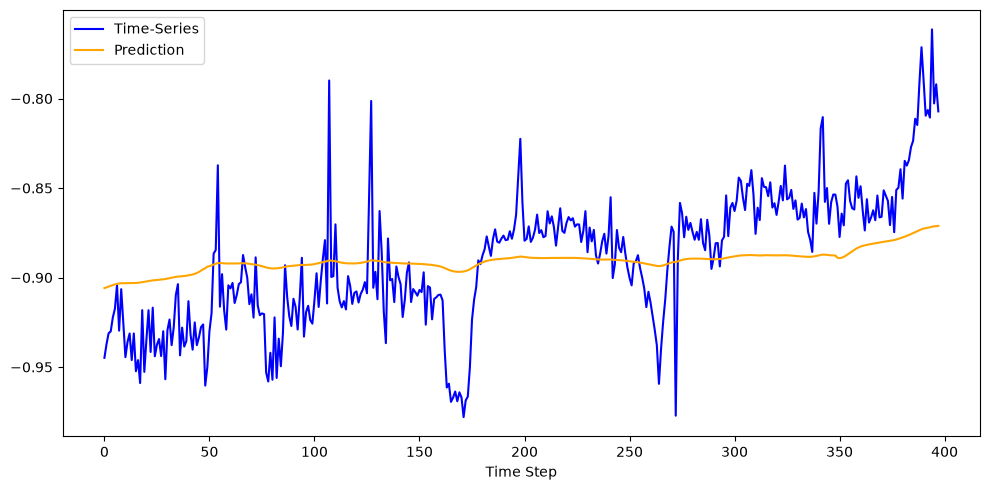

--------------
AWS Signal 16
--------------
Epoch  25 | GG Loss: 0.122226 | GF Loss: -0.302755 | FC Loss: 0.065114 | DX Loss: -0.012111 | DZ Loss: -7.733193
Epoch  50 | GG Loss: -2.359308 | GF Loss: -0.450002 | FC Loss: 0.065226 | DX Loss: -0.143144 | DZ Loss: -46.959901
Epoch  75 | GG Loss: -2.897302 | GF Loss: -0.815146 | FC Loss: 0.069614 | DX Loss: -0.491823 | DZ Loss: -71.224816
Epoch 100 | GG Loss: -1.214700 | GF Loss: 0.296931 | FC Loss: 0.066261 | DX Loss: -1.554222 | DZ Loss: -78.611875
Epoch 125 | GG Loss: -0.893971 | GF Loss: 1.205913 | FC Loss: 0.064319 | DX Loss: -1.189099 | DZ Loss: -81.406130
Epoch 150 | GG Loss: -1.496146 | GF Loss: 2.175478 | FC Loss: 0.063853 | DX Loss: -1.050776 | DZ Loss: -81.611315
Epoch 175 | GG Loss: -1.984939 | GF Loss: 1.765563 | FC Loss: 0.061676 | DX Loss: 0.473405 | DZ Loss: -81.441705
Epoch 200 | GG Loss: -1.302952 | GF Loss: 6.106946 | FC Loss: 0.064517 | DX Loss: 0.937905 | DZ Loss: -81.595149
Epoch 225 | GG Loss: -1.013459 | GF Loss: 8.7

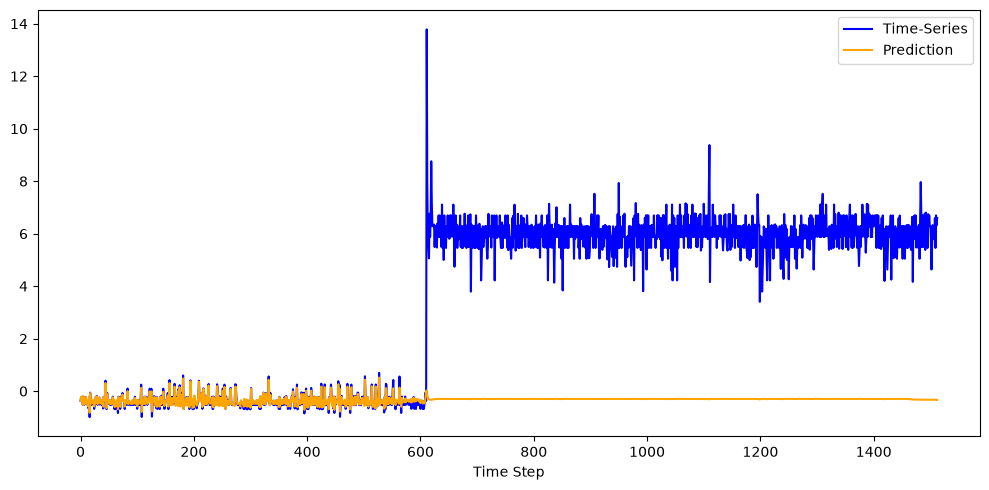

--------------
AWS Signal 17
--------------
Epoch  25 | GG Loss: 0.542974 | GF Loss: -5.342197 | FC Loss: 0.049859 | DX Loss: -0.732166 | DZ Loss: -4.522968
Epoch  50 | GG Loss: -2.354313 | GF Loss: 0.110720 | FC Loss: 0.013405 | DX Loss: -0.389816 | DZ Loss: -39.519021
Epoch  75 | GG Loss: -2.801614 | GF Loss: -0.177437 | FC Loss: 0.012257 | DX Loss: -0.587697 | DZ Loss: -68.969225
Epoch 100 | GG Loss: -1.217499 | GF Loss: -0.046443 | FC Loss: 0.010092 | DX Loss: -0.548292 | DZ Loss: -78.086400
Epoch 125 | GG Loss: -1.251471 | GF Loss: -0.169080 | FC Loss: 0.008344 | DX Loss: -0.402481 | DZ Loss: -81.407858
Epoch 150 | GG Loss: -1.271469 | GF Loss: -0.264363 | FC Loss: 0.007470 | DX Loss: -0.230171 | DZ Loss: -82.717811
Epoch 175 | GG Loss: -1.333208 | GF Loss: -0.278925 | FC Loss: 0.007874 | DX Loss: -0.093635 | DZ Loss: -83.150456
Epoch 200 | GG Loss: -1.305483 | GF Loss: -0.346429 | FC Loss: 0.008081 | DX Loss: 0.151906 | DZ Loss: -83.356912
Epoch 225 | GG Loss: -1.248375 | GF Loss

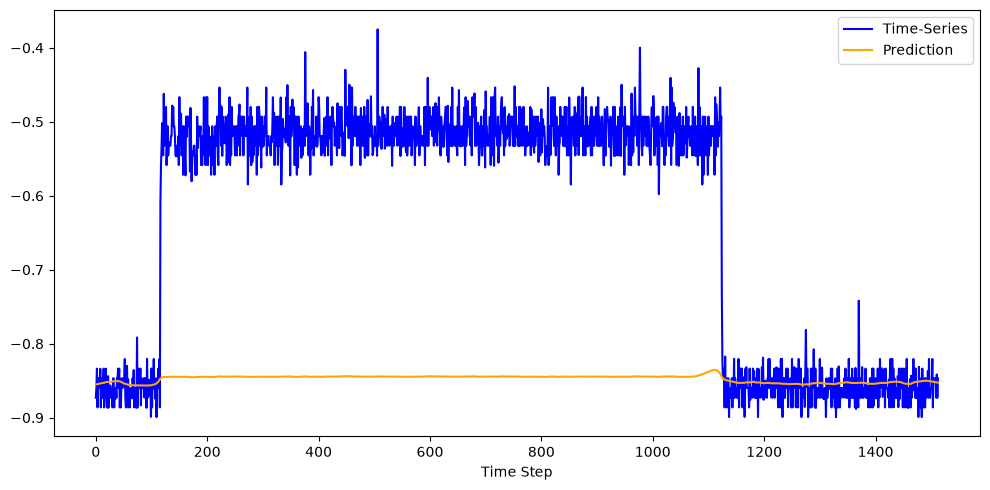

------------------
AWS Metrics
------------------
[point] Precision: 0.728 | Recall: 1.083 | F1: 0.806
[area] Precision: 0.467 | Recall: 1.333 | F1: 0.615


In [25]:
total_metrics = {name: np.zeros(3) for (name, _) in NAB_HYPERPARAMS["rec_error_funcs"]}

for i, aws_signal in enumerate(aws_signals):
    X = aws_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = aws_signal['is_anomaly'].to_numpy()
    
    print("--------------")
    print(f"AWS Signal {i + 1}")
    print("--------------")

    metrics = run_pipeline(X, y, **NAB_HYPERPARAMS)

    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])

print("------------------")
print("AWS Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / len(art_signals)
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

### **Real Traffic**

In [26]:
traffic_signals = nab_download_subdataset(folder=TRAFFIC_FOLDER, file_names=TRAFFIC_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading realTraffic/!
---------------------
Total Signals: 7
Total Points: 15664
Total Anomaly Points: 1560
Anomaly Rate: 9.96%


--------------
Traffic Signal 1
--------------
Epoch  25 | GG Loss: -0.018421 | GF Loss: -1.762872 | FC Loss: 0.121638 | DX Loss: -2.042403 | DZ Loss: 0.020988
Epoch  50 | GG Loss: 0.914400 | GF Loss: -6.816883 | FC Loss: 0.076174 | DX Loss: 0.305011 | DZ Loss: -3.976120
Epoch  75 | GG Loss: 2.389187 | GF Loss: 1.189833 | FC Loss: 0.026207 | DX Loss: -0.664033 | DZ Loss: -22.234273
Epoch 100 | GG Loss: -1.387599 | GF Loss: 1.470962 | FC Loss: 0.033327 | DX Loss: -0.476250 | DZ Loss: -43.902424
Epoch 125 | GG Loss: -2.551777 | GF Loss: -0.071165 | FC Loss: 0.023364 | DX Loss: -0.718939 | DZ Loss: -60.499846
Epoch 150 | GG Loss: -1.762348 | GF Loss: -0.200390 | FC Loss: 0.021466 | DX Loss: -0.723970 | DZ Loss: -70.659207
Epoch 175 | GG Loss: -1.396558 | GF Loss: -0.103323 | FC Loss: 0.020143 | DX Loss: -0.666617 | DZ Loss: -76.434321
Epoch 200 | GG Loss: -3.637800 | GF Loss: -0.407925 | FC Loss: 0.018405 | DX Loss: -0.585084 | DZ Loss: -78.379645
Epoch 225 | GG Loss: -3.424909 | GF Loss:

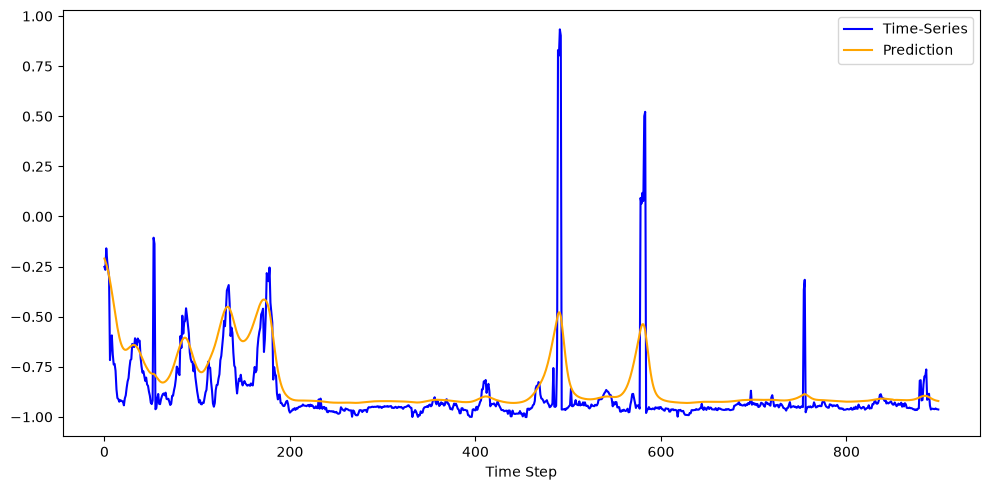

--------------
Traffic Signal 2
--------------
Epoch  25 | GG Loss: 0.212303 | GF Loss: 0.314620 | FC Loss: 0.324341 | DX Loss: -0.307541 | DZ Loss: 0.559386
Epoch  50 | GG Loss: 1.403308 | GF Loss: -1.752660 | FC Loss: 0.065078 | DX Loss: -1.026823 | DZ Loss: -3.642981
Epoch  75 | GG Loss: 0.950502 | GF Loss: -2.856970 | FC Loss: 0.077877 | DX Loss: 0.495468 | DZ Loss: -16.371279
Epoch 100 | GG Loss: -2.818796 | GF Loss: -0.726072 | FC Loss: 0.049855 | DX Loss: -0.003565 | DZ Loss: -35.895559
Epoch 125 | GG Loss: -5.595991 | GF Loss: 0.565826 | FC Loss: 0.045564 | DX Loss: -0.518454 | DZ Loss: -54.539643
Epoch 150 | GG Loss: -5.482886 | GF Loss: 0.374762 | FC Loss: 0.043340 | DX Loss: -0.660380 | DZ Loss: -65.126978
Epoch 175 | GG Loss: -3.718848 | GF Loss: 0.228421 | FC Loss: 0.040924 | DX Loss: -0.672335 | DZ Loss: -71.988693
Epoch 200 | GG Loss: -2.074127 | GF Loss: 0.303004 | FC Loss: 0.039558 | DX Loss: -0.627868 | DZ Loss: -76.551180
Epoch 225 | GG Loss: -1.555223 | GF Loss: 0.3

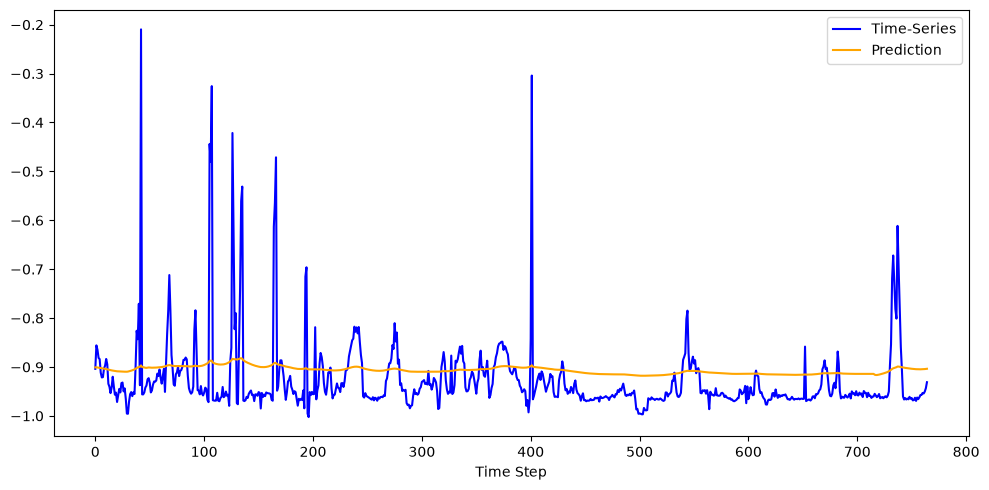

--------------
Traffic Signal 3
--------------
Epoch  25 | GG Loss: 0.000513 | GF Loss: -2.281999 | FC Loss: 0.096512 | DX Loss: -0.926992 | DZ Loss: 0.319920
Epoch  50 | GG Loss: -0.007164 | GF Loss: -3.092096 | FC Loss: 0.122088 | DX Loss: 0.852839 | DZ Loss: -3.206991
Epoch  75 | GG Loss: 0.473079 | GF Loss: 0.496150 | FC Loss: 0.090796 | DX Loss: -0.198638 | DZ Loss: -20.778619
Epoch 100 | GG Loss: -2.684496 | GF Loss: 0.903309 | FC Loss: 0.092979 | DX Loss: -0.063397 | DZ Loss: -42.557337
Epoch 125 | GG Loss: -4.684735 | GF Loss: 0.275610 | FC Loss: 0.086164 | DX Loss: -0.153774 | DZ Loss: -60.209648
Epoch 150 | GG Loss: -3.847055 | GF Loss: -0.052070 | FC Loss: 0.082884 | DX Loss: -0.207284 | DZ Loss: -69.441828
Epoch 175 | GG Loss: -3.565148 | GF Loss: -0.514136 | FC Loss: 0.080406 | DX Loss: -0.244395 | DZ Loss: -74.276866
Epoch 200 | GG Loss: -3.053738 | GF Loss: -0.398887 | FC Loss: 0.076136 | DX Loss: -0.237560 | DZ Loss: -77.371972
Epoch 225 | GG Loss: -1.854027 | GF Loss: 

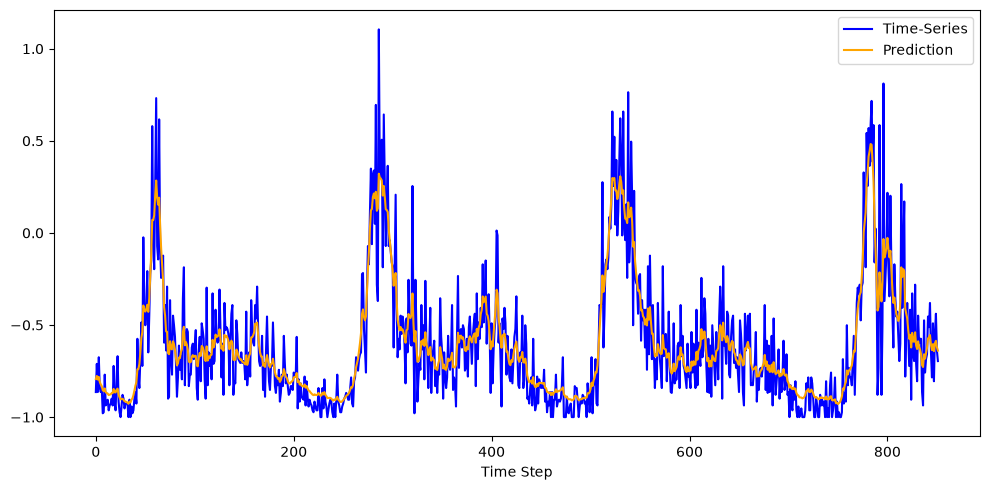

--------------
Traffic Signal 4
--------------
Epoch  25 | GG Loss: 0.371942 | GF Loss: 0.072533 | FC Loss: 0.133195 | DX Loss: 0.082130 | DZ Loss: -0.847020
Epoch  50 | GG Loss: 1.081416 | GF Loss: -0.409058 | FC Loss: 0.101659 | DX Loss: -0.023569 | DZ Loss: -12.068636
Epoch  75 | GG Loss: -0.931202 | GF Loss: -0.059032 | FC Loss: 0.101576 | DX Loss: 0.057472 | DZ Loss: -34.541945
Epoch 100 | GG Loss: -3.767651 | GF Loss: 0.890227 | FC Loss: 0.095700 | DX Loss: -0.142730 | DZ Loss: -57.214802
Epoch 125 | GG Loss: -3.407560 | GF Loss: 2.200711 | FC Loss: 0.092579 | DX Loss: -0.541840 | DZ Loss: -68.986762
Epoch 150 | GG Loss: -2.382032 | GF Loss: 3.505519 | FC Loss: 0.078851 | DX Loss: -0.612781 | DZ Loss: -74.881155
Epoch 175 | GG Loss: -1.538247 | GF Loss: 1.343478 | FC Loss: 0.058875 | DX Loss: 1.067309 | DZ Loss: -78.111148
Epoch 200 | GG Loss: -0.858032 | GF Loss: 1.760742 | FC Loss: 0.052296 | DX Loss: 0.016984 | DZ Loss: -79.799787
Epoch 225 | GG Loss: -0.448142 | GF Loss: 3.07

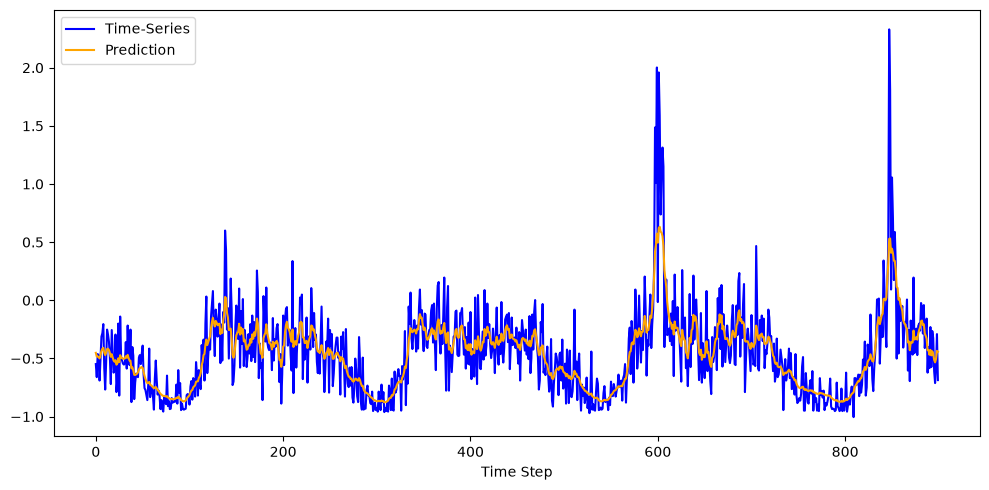

--------------
Traffic Signal 5
--------------
Epoch  25 | GG Loss: 0.092618 | GF Loss: -0.160643 | FC Loss: 0.067931 | DX Loss: 0.089207 | DZ Loss: -0.226042
Epoch  50 | GG Loss: 0.145074 | GF Loss: -0.062999 | FC Loss: 0.066993 | DX Loss: 0.004599 | DZ Loss: -8.257566
Epoch  75 | GG Loss: -0.564211 | GF Loss: -0.044688 | FC Loss: 0.066438 | DX Loss: -0.012357 | DZ Loss: -30.415645
Epoch 100 | GG Loss: -3.322776 | GF Loss: -0.032909 | FC Loss: 0.065880 | DX Loss: -0.027100 | DZ Loss: -53.622553
Epoch 125 | GG Loss: -4.531527 | GF Loss: -0.027022 | FC Loss: 0.065762 | DX Loss: -0.032541 | DZ Loss: -66.770932
Epoch 150 | GG Loss: -3.755992 | GF Loss: -0.023372 | FC Loss: 0.065524 | DX Loss: -0.031741 | DZ Loss: -74.325300
Epoch 175 | GG Loss: -2.602129 | GF Loss: -0.039307 | FC Loss: 0.065311 | DX Loss: -0.022082 | DZ Loss: -78.520976
Epoch 200 | GG Loss: -2.194351 | GF Loss: -0.072576 | FC Loss: 0.065139 | DX Loss: 0.009190 | DZ Loss: -80.484629
Epoch 225 | GG Loss: -2.092628 | GF Loss

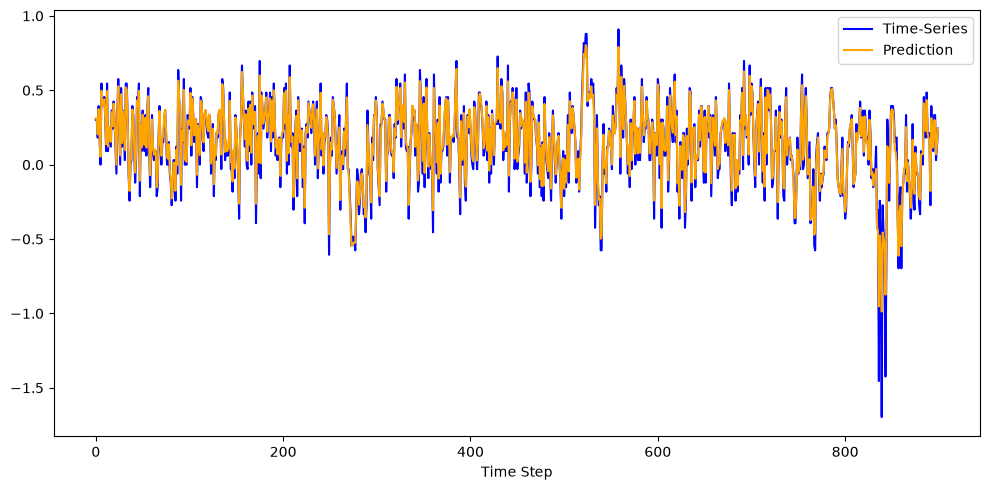

--------------
Traffic Signal 6
--------------
Epoch  25 | GG Loss: 0.069156 | GF Loss: -0.079706 | FC Loss: 0.063210 | DX Loss: 2.273660 | DZ Loss: 3.542032
Epoch  50 | GG Loss: 0.136297 | GF Loss: -0.427709 | FC Loss: 0.025925 | DX Loss: 0.012772 | DZ Loss: 0.162153
Epoch  75 | GG Loss: 0.164189 | GF Loss: -0.786658 | FC Loss: 0.032163 | DX Loss: 0.222095 | DZ Loss: -0.059615
Epoch 100 | GG Loss: 0.226700 | GF Loss: -0.466370 | FC Loss: 0.029810 | DX Loss: 0.191531 | DZ Loss: -0.862756
Epoch 125 | GG Loss: 0.285087 | GF Loss: -0.022312 | FC Loss: 0.024925 | DX Loss: 0.055609 | DZ Loss: -3.999350
Epoch 150 | GG Loss: 0.453908 | GF Loss: 0.104261 | FC Loss: 0.025588 | DX Loss: 0.044920 | DZ Loss: -10.150352
Epoch 175 | GG Loss: 0.708071 | GF Loss: 0.024904 | FC Loss: 0.025311 | DX Loss: 0.031830 | DZ Loss: -19.290884
Epoch 200 | GG Loss: -0.010566 | GF Loss: -0.064206 | FC Loss: 0.024801 | DX Loss: 0.005755 | DZ Loss: -28.487252
Epoch 225 | GG Loss: -2.140915 | GF Loss: -0.086809 | FC 

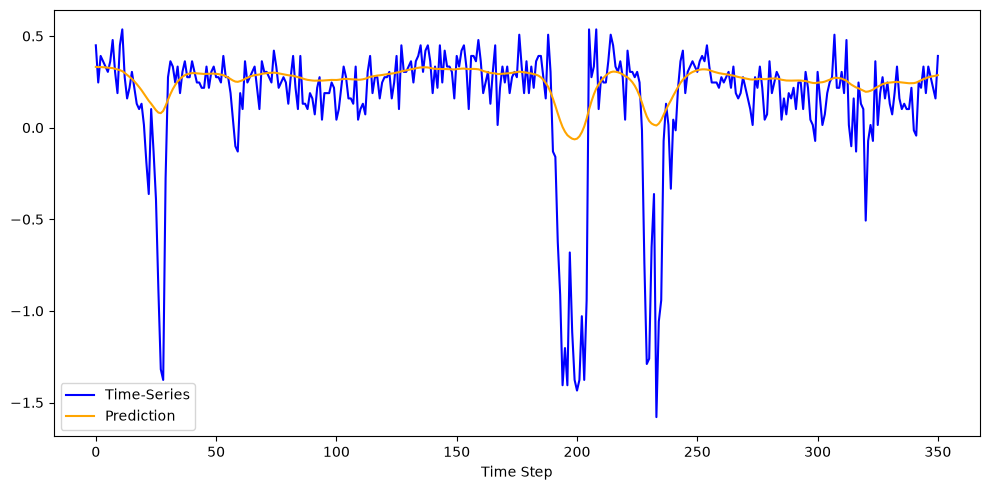

--------------
Traffic Signal 7
--------------
Epoch  25 | GG Loss: -0.231895 | GF Loss: -0.049207 | FC Loss: 0.036183 | DX Loss: 0.051737 | DZ Loss: 0.196705
Epoch  50 | GG Loss: 0.568713 | GF Loss: -0.064013 | FC Loss: 0.035287 | DX Loss: -0.036403 | DZ Loss: -0.796437
Epoch  75 | GG Loss: 0.196326 | GF Loss: -0.044273 | FC Loss: 0.036152 | DX Loss: 0.015561 | DZ Loss: -11.306837
Epoch 100 | GG Loss: -2.227607 | GF Loss: -0.040806 | FC Loss: 0.034589 | DX Loss: -0.022351 | DZ Loss: -33.554075
Epoch 125 | GG Loss: -3.369473 | GF Loss: 0.001385 | FC Loss: 0.034521 | DX Loss: -0.074300 | DZ Loss: -55.266212
Epoch 150 | GG Loss: -2.665672 | GF Loss: 0.006120 | FC Loss: 0.034220 | DX Loss: -0.123527 | DZ Loss: -67.151593
Epoch 175 | GG Loss: -1.519251 | GF Loss: 0.010005 | FC Loss: 0.034076 | DX Loss: -0.141651 | DZ Loss: -74.788825
Epoch 200 | GG Loss: -1.046695 | GF Loss: -0.025560 | FC Loss: 0.033836 | DX Loss: -0.143708 | DZ Loss: -79.103352
Epoch 225 | GG Loss: -1.186995 | GF Loss: -

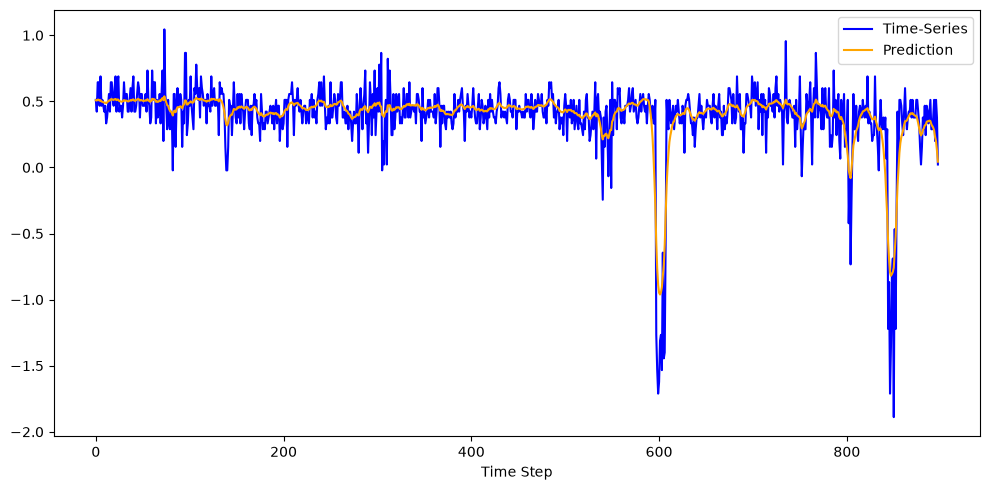

------------------
Real Traffic Metrics
------------------
[point] Precision: 0.000 | Recall: 0.000 | F1: 0.000
[area] Precision: 0.226 | Recall: 0.571 | F1: 0.314


In [27]:
total_metrics = {name: np.zeros(3) for (name, _) in NAB_HYPERPARAMS["rec_error_funcs"]}

for i, traffic_signal in enumerate(traffic_signals):
    X = traffic_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = traffic_signal['is_anomaly'].to_numpy()

    print("--------------")
    print(f"Traffic Signal {i + 1}")
    print("--------------")

    metrics = run_pipeline(X, y, **NAB_HYPERPARAMS)

    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])

print("------------------")
print("Real Traffic Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / len(traffic_signals)
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

### **Twitter**

In [28]:
twitter_signals = nab_download_subdataset(folder=TWEETS_FOLDER, file_names=TWEETS_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.
Downloaded 10 .csv files.

Finished downloading realTweets/!
---------------------
Total Signals: 10
Total Points: 158631
Total Anomaly Points: 15651
Anomaly Rate: 9.87%


--------------
Twitter Signal 1
--------------
Epoch  25 | GG Loss: -1.723004 | GF Loss: 0.015919 | FC Loss: 0.009417 | DX Loss: -0.639249 | DZ Loss: -74.464431
Epoch  50 | GG Loss: -1.397698 | GF Loss: 0.097275 | FC Loss: 0.003134 | DX Loss: 0.023846 | DZ Loss: -82.298048
Epoch  75 | GG Loss: -1.199878 | GF Loss: 0.146581 | FC Loss: 0.002109 | DX Loss: -0.002793 | DZ Loss: -82.879897
Epoch 100 | GG Loss: -1.374722 | GF Loss: -3.066438 | FC Loss: 0.003324 | DX Loss: -0.085768 | DZ Loss: -83.156934
Epoch 125 | GG Loss: -1.508277 | GF Loss: 1.095181 | FC Loss: 0.002861 | DX Loss: -0.030865 | DZ Loss: -83.201352
Epoch 150 | GG Loss: -1.736769 | GF Loss: -2.801761 | FC Loss: 0.002700 | DX Loss: -0.117615 | DZ Loss: -83.266658
Epoch 175 | GG Loss: -1.852873 | GF Loss: 0.931227 | FC Loss: 0.002658 | DX Loss: -0.018775 | DZ Loss: -83.293073
Epoch 200 | GG Loss: -1.541436 | GF Loss: -0.949026 | FC Loss: 0.002522 | DX Loss: -0.120118 | DZ Loss: -83.151933
Epoch 225 | GG Loss: -2.140810 | GF Los

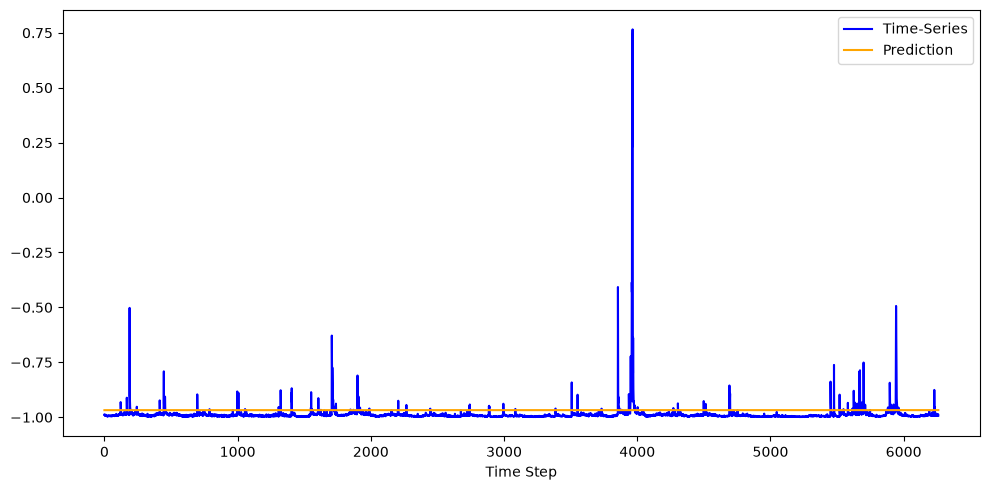

--------------
Twitter Signal 2
--------------
Epoch  25 | GG Loss: -3.202969 | GF Loss: -0.298377 | FC Loss: 0.007191 | DX Loss: -0.681465 | DZ Loss: -75.014240
Epoch  50 | GG Loss: -1.674285 | GF Loss: -0.054554 | FC Loss: 0.002279 | DX Loss: 0.048769 | DZ Loss: -82.361962
Epoch  75 | GG Loss: -1.682414 | GF Loss: -0.024744 | FC Loss: 0.001930 | DX Loss: -0.006034 | DZ Loss: -82.577894
Epoch 100 | GG Loss: -2.186231 | GF Loss: 0.637360 | FC Loss: 0.001887 | DX Loss: -0.005886 | DZ Loss: -82.241796
Epoch 125 | GG Loss: -1.736334 | GF Loss: 0.376818 | FC Loss: 0.001782 | DX Loss: -0.005129 | DZ Loss: -82.229415
Epoch 150 | GG Loss: -1.890799 | GF Loss: 1.333302 | FC Loss: 0.001806 | DX Loss: -0.004802 | DZ Loss: -82.380879
Epoch 175 | GG Loss: -2.172404 | GF Loss: 1.010453 | FC Loss: 0.001759 | DX Loss: -0.005225 | DZ Loss: -82.317145
Epoch 200 | GG Loss: -1.782632 | GF Loss: 2.600201 | FC Loss: 0.001716 | DX Loss: -0.006632 | DZ Loss: -82.458458
Epoch 225 | GG Loss: -2.297373 | GF Los

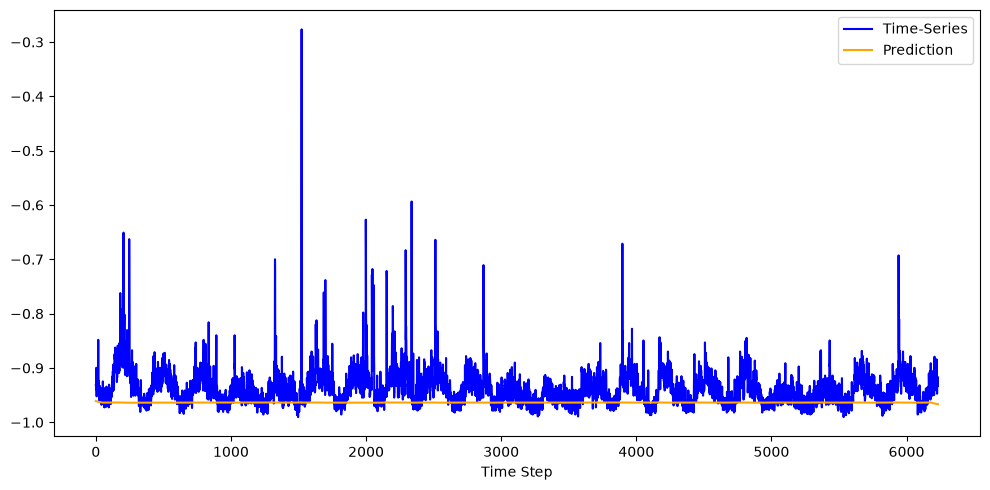

--------------
Twitter Signal 3
--------------
Epoch  25 | GG Loss: -1.846746 | GF Loss: 0.672580 | FC Loss: 0.010828 | DX Loss: -0.336382 | DZ Loss: -73.454447
Epoch  50 | GG Loss: -1.227748 | GF Loss: 2.691780 | FC Loss: 0.022486 | DX Loss: 1.303526 | DZ Loss: -82.799455
Epoch  75 | GG Loss: -1.152561 | GF Loss: 9.660148 | FC Loss: 0.003938 | DX Loss: -0.053235 | DZ Loss: -83.101299
Epoch 100 | GG Loss: -1.080457 | GF Loss: 9.529240 | FC Loss: 0.003517 | DX Loss: -0.007391 | DZ Loss: -83.083885
Epoch 125 | GG Loss: -1.348825 | GF Loss: 14.283364 | FC Loss: 0.002888 | DX Loss: 0.015605 | DZ Loss: -83.006805
Epoch 150 | GG Loss: -1.102652 | GF Loss: 10.561032 | FC Loss: 0.003235 | DX Loss: -0.030394 | DZ Loss: -83.079573
Epoch 175 | GG Loss: -1.166169 | GF Loss: 14.460891 | FC Loss: 0.003837 | DX Loss: -0.035744 | DZ Loss: -82.848552
Epoch 200 | GG Loss: -1.236465 | GF Loss: 10.880467 | FC Loss: 0.003946 | DX Loss: -0.156780 | DZ Loss: -83.301420
Epoch 225 | GG Loss: -1.376593 | GF Los

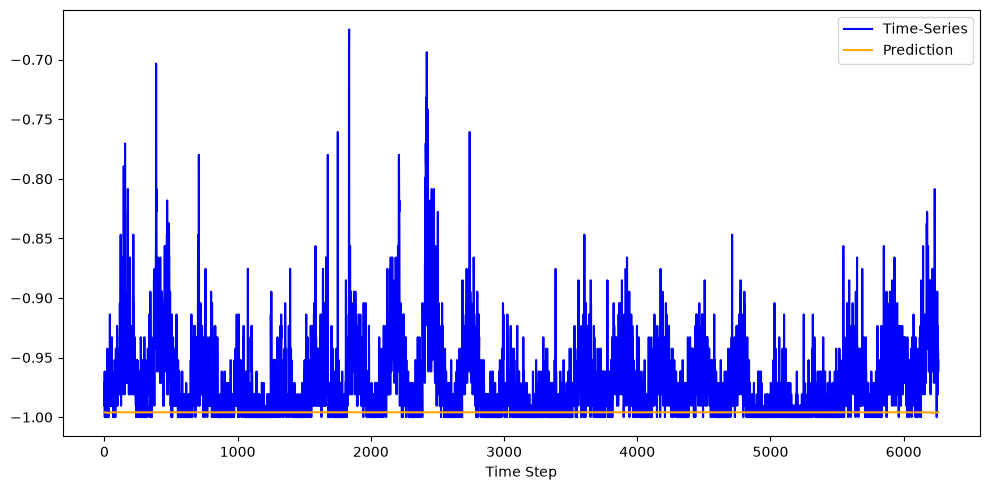

--------------
Twitter Signal 4
--------------
Epoch  25 | GG Loss: -4.209929 | GF Loss: 0.027594 | FC Loss: 0.009315 | DX Loss: -0.670609 | DZ Loss: -74.160627
Epoch  50 | GG Loss: -1.293780 | GF Loss: 1.127559 | FC Loss: 0.002388 | DX Loss: -0.032360 | DZ Loss: -82.197176
Epoch  75 | GG Loss: -1.318965 | GF Loss: 0.667992 | FC Loss: 0.001854 | DX Loss: -0.003858 | DZ Loss: -82.409092
Epoch 100 | GG Loss: -1.272480 | GF Loss: 1.934059 | FC Loss: 0.002375 | DX Loss: -0.009183 | DZ Loss: -82.553481
Epoch 125 | GG Loss: -1.456956 | GF Loss: 4.884574 | FC Loss: 0.002132 | DX Loss: -0.058384 | DZ Loss: -82.486747
Epoch 150 | GG Loss: -1.815372 | GF Loss: 9.473347 | FC Loss: 0.002280 | DX Loss: -0.009468 | DZ Loss: -82.160293
Epoch 175 | GG Loss: -1.617423 | GF Loss: 11.151915 | FC Loss: 0.002153 | DX Loss: -0.123292 | DZ Loss: -82.104294
Epoch 200 | GG Loss: -2.062651 | GF Loss: 13.688175 | FC Loss: 0.002328 | DX Loss: -0.036592 | DZ Loss: -81.885512
Epoch 225 | GG Loss: -2.663615 | GF Los

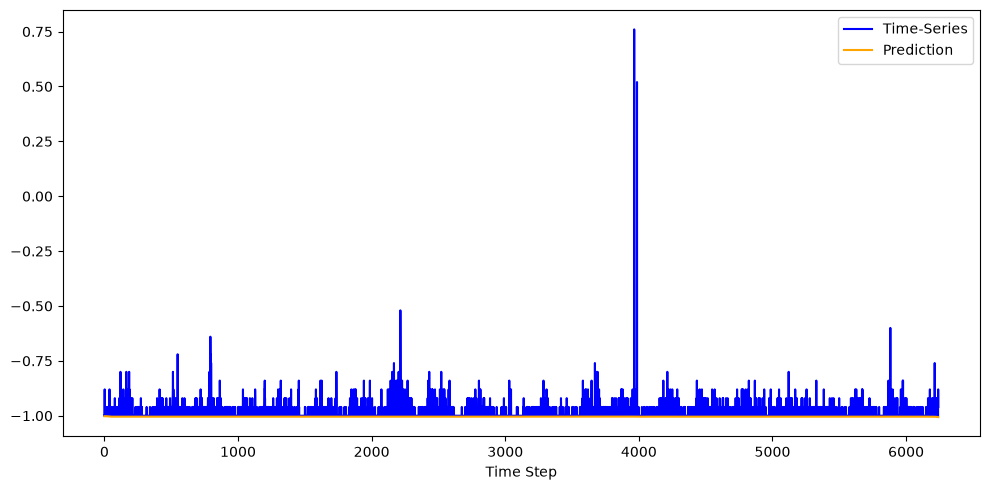

--------------
Twitter Signal 5
--------------
Epoch  25 | GG Loss: -4.649189 | GF Loss: 0.170637 | FC Loss: 0.009832 | DX Loss: -0.699094 | DZ Loss: -75.754774
Epoch  50 | GG Loss: -1.983440 | GF Loss: -0.463742 | FC Loss: 0.013634 | DX Loss: 0.278566 | DZ Loss: -82.254754
Epoch  75 | GG Loss: -2.150149 | GF Loss: 0.499455 | FC Loss: 0.003255 | DX Loss: 0.006991 | DZ Loss: -82.127988
Epoch 100 | GG Loss: -1.867858 | GF Loss: -0.358742 | FC Loss: 0.002967 | DX Loss: -0.003305 | DZ Loss: -82.117317
Epoch 125 | GG Loss: -2.148456 | GF Loss: -0.971369 | FC Loss: 0.002861 | DX Loss: -0.008586 | DZ Loss: -82.090030
Epoch 150 | GG Loss: -2.075349 | GF Loss: -5.995735 | FC Loss: 0.023080 | DX Loss: -0.234826 | DZ Loss: -82.240078
Epoch 175 | GG Loss: -2.521875 | GF Loss: -4.386815 | FC Loss: 0.003327 | DX Loss: 0.005009 | DZ Loss: -81.795818
Epoch 200 | GG Loss: -2.326871 | GF Loss: -0.605082 | FC Loss: 0.006807 | DX Loss: -0.063476 | DZ Loss: -81.726690
Epoch 225 | GG Loss: -2.827365 | GF Lo

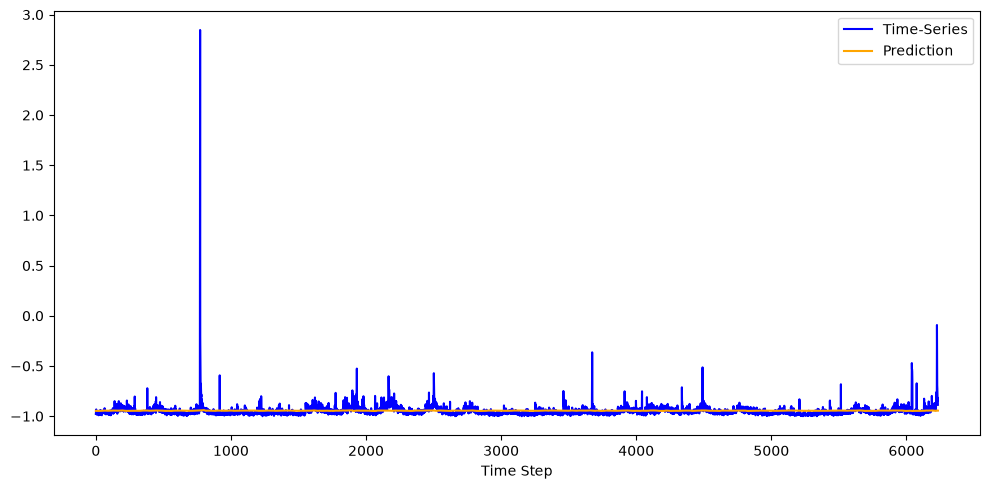

--------------
Twitter Signal 6
--------------
Epoch  25 | GG Loss: -1.127833 | GF Loss: 0.280675 | FC Loss: 0.013268 | DX Loss: -0.660289 | DZ Loss: -75.946397
Epoch  50 | GG Loss: -0.533220 | GF Loss: -0.021178 | FC Loss: 0.008504 | DX Loss: -0.122656 | DZ Loss: -82.241619
Epoch  75 | GG Loss: -0.297851 | GF Loss: -0.116604 | FC Loss: 0.007166 | DX Loss: -0.007779 | DZ Loss: -82.522988
Epoch 100 | GG Loss: -0.399422 | GF Loss: -0.005816 | FC Loss: 0.006740 | DX Loss: 0.012634 | DZ Loss: -82.273085
Epoch 125 | GG Loss: -0.615728 | GF Loss: 0.850883 | FC Loss: 0.009600 | DX Loss: -0.015016 | DZ Loss: -82.305667
Epoch 150 | GG Loss: -0.719924 | GF Loss: -3.962033 | FC Loss: 0.024213 | DX Loss: -0.325167 | DZ Loss: -82.334745
Epoch 175 | GG Loss: -0.610601 | GF Loss: 2.444623 | FC Loss: 0.007778 | DX Loss: 0.126532 | DZ Loss: -82.295086
Epoch 200 | GG Loss: -0.795967 | GF Loss: 2.266579 | FC Loss: 0.007078 | DX Loss: 0.028394 | DZ Loss: -81.757606
Epoch 225 | GG Loss: -1.082503 | GF Loss

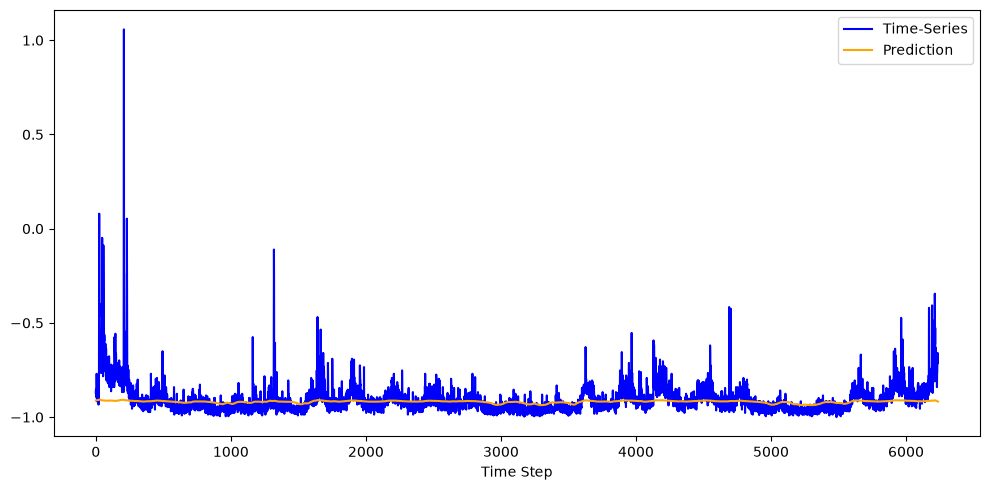

--------------
Twitter Signal 7
--------------
Epoch  25 | GG Loss: -2.021910 | GF Loss: -0.229633 | FC Loss: 0.019460 | DX Loss: -0.871936 | DZ Loss: -74.686219
Epoch  50 | GG Loss: -0.303751 | GF Loss: -0.119569 | FC Loss: 0.012406 | DX Loss: -0.314674 | DZ Loss: -82.063745
Epoch  75 | GG Loss: -0.410567 | GF Loss: 0.112065 | FC Loss: 0.010410 | DX Loss: -0.064069 | DZ Loss: -82.327854
Epoch 100 | GG Loss: -0.328788 | GF Loss: 0.199434 | FC Loss: 0.010974 | DX Loss: 0.122078 | DZ Loss: -82.315284
Epoch 125 | GG Loss: -0.568389 | GF Loss: 0.019155 | FC Loss: 0.011373 | DX Loss: 0.000270 | DZ Loss: -82.160609
Epoch 150 | GG Loss: -0.591275 | GF Loss: 0.011854 | FC Loss: 0.009566 | DX Loss: -0.005910 | DZ Loss: -81.998528
Epoch 175 | GG Loss: -0.628569 | GF Loss: -0.712080 | FC Loss: 0.009583 | DX Loss: -0.001936 | DZ Loss: -81.970208
Epoch 200 | GG Loss: -0.763907 | GF Loss: 1.591105 | FC Loss: 0.010993 | DX Loss: -0.000605 | DZ Loss: -81.896106
Epoch 225 | GG Loss: -0.940895 | GF Loss

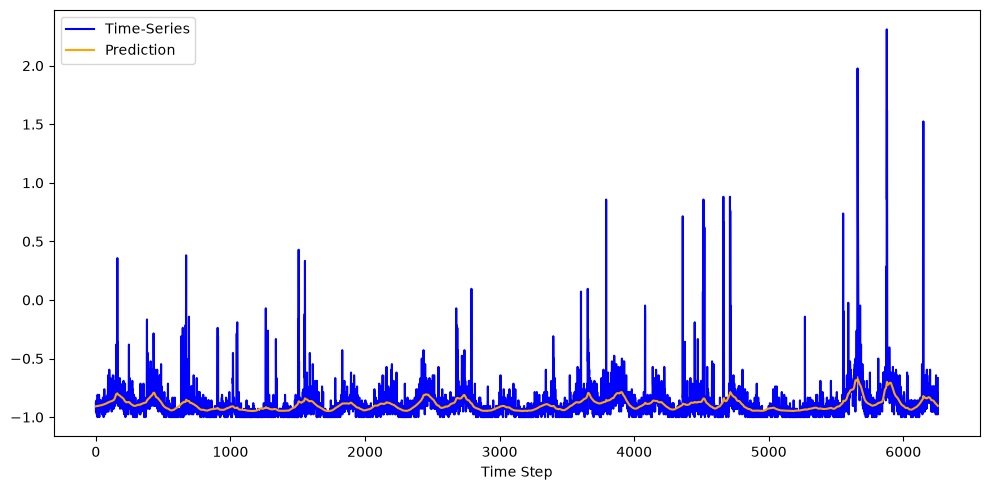

--------------
Twitter Signal 8
--------------
Epoch  25 | GG Loss: -2.775517 | GF Loss: -0.375235 | FC Loss: 0.010615 | DX Loss: -0.598766 | DZ Loss: -75.200758
Epoch  50 | GG Loss: -2.167703 | GF Loss: -0.633764 | FC Loss: 0.011196 | DX Loss: 0.114966 | DZ Loss: -82.616871
Epoch  75 | GG Loss: -2.054847 | GF Loss: 0.551251 | FC Loss: 0.006511 | DX Loss: 0.096759 | DZ Loss: -82.857910
Epoch 100 | GG Loss: -2.009487 | GF Loss: 2.375796 | FC Loss: 0.004454 | DX Loss: 0.015241 | DZ Loss: -82.823980
Epoch 125 | GG Loss: -2.066018 | GF Loss: 1.530690 | FC Loss: 0.004445 | DX Loss: -0.002335 | DZ Loss: -82.843803
Epoch 150 | GG Loss: -2.273514 | GF Loss: 0.508389 | FC Loss: 0.004831 | DX Loss: 0.001593 | DZ Loss: -82.698972
Epoch 175 | GG Loss: -2.312141 | GF Loss: 0.368674 | FC Loss: 0.004525 | DX Loss: -0.007194 | DZ Loss: -82.677852
Epoch 200 | GG Loss: -2.459759 | GF Loss: 0.946121 | FC Loss: 0.005021 | DX Loss: 0.001037 | DZ Loss: -82.380873
Epoch 225 | GG Loss: -2.225081 | GF Loss: 0.

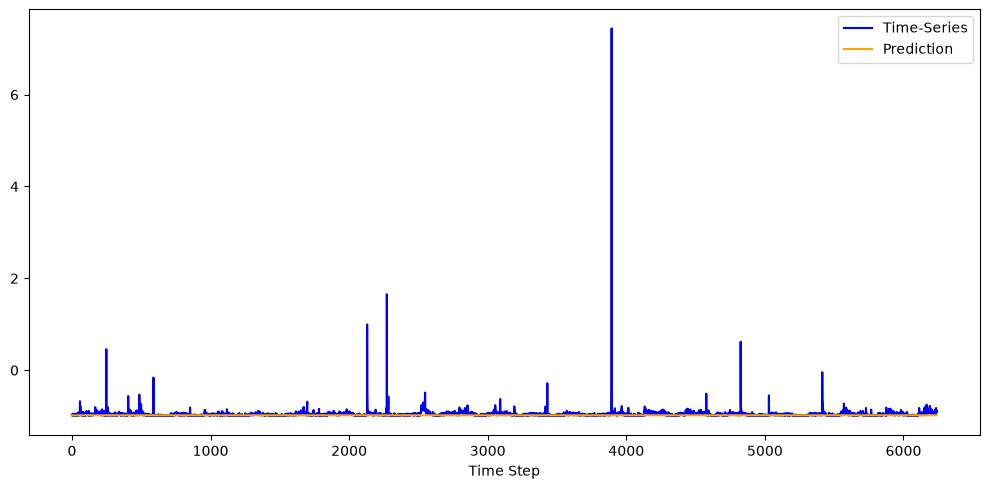

--------------
Twitter Signal 9
--------------
Epoch  25 | GG Loss: -3.536818 | GF Loss: -0.043172 | FC Loss: 0.015991 | DX Loss: -0.760987 | DZ Loss: -75.891070
Epoch  50 | GG Loss: -1.402810 | GF Loss: 0.374618 | FC Loss: 0.007289 | DX Loss: 0.026025 | DZ Loss: -82.361059
Epoch  75 | GG Loss: -1.483816 | GF Loss: -0.152461 | FC Loss: 0.006371 | DX Loss: -0.007159 | DZ Loss: -82.500356
Epoch 100 | GG Loss: -2.059739 | GF Loss: 1.085738 | FC Loss: 0.006098 | DX Loss: -0.002096 | DZ Loss: -82.256815
Epoch 125 | GG Loss: -1.658864 | GF Loss: 3.414700 | FC Loss: 0.014036 | DX Loss: -0.108157 | DZ Loss: -82.451218
Epoch 150 | GG Loss: -1.664580 | GF Loss: 12.713144 | FC Loss: 0.006096 | DX Loss: -0.031785 | DZ Loss: -82.335112
Epoch 175 | GG Loss: -2.068932 | GF Loss: 17.627403 | FC Loss: 0.006334 | DX Loss: -0.033527 | DZ Loss: -81.920756
Epoch 200 | GG Loss: -1.780299 | GF Loss: 18.752291 | FC Loss: 0.006467 | DX Loss: 0.351337 | DZ Loss: -82.135435
Epoch 225 | GG Loss: -2.857728 | GF Lo

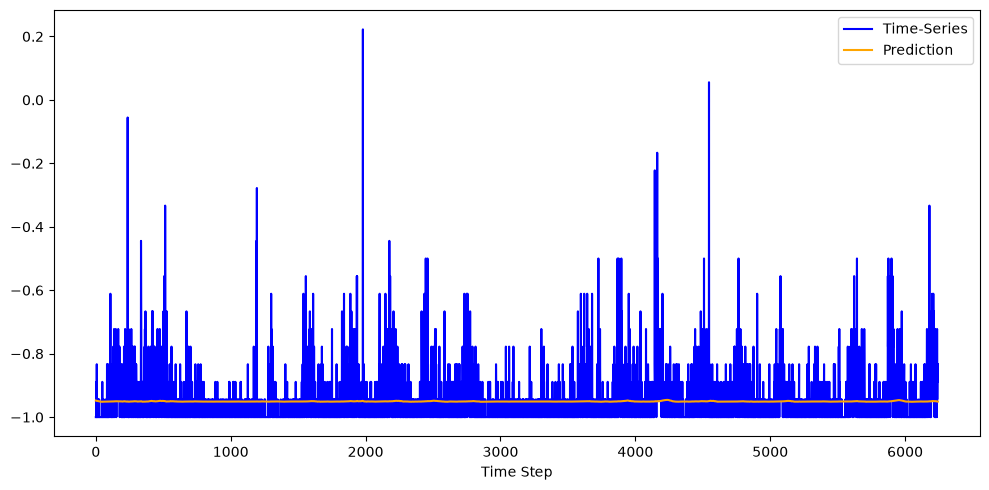

--------------
Twitter Signal 10
--------------
Epoch  25 | GG Loss: -2.019496 | GF Loss: 0.120484 | FC Loss: 0.046895 | DX Loss: -0.595606 | DZ Loss: -73.722959
Epoch  50 | GG Loss: -1.207919 | GF Loss: 0.501835 | FC Loss: 0.041574 | DX Loss: -0.144423 | DZ Loss: -82.060930
Epoch  75 | GG Loss: -1.550943 | GF Loss: 3.442364 | FC Loss: 0.043422 | DX Loss: -0.104312 | DZ Loss: -81.967980
Epoch 100 | GG Loss: -1.438024 | GF Loss: -6.097917 | FC Loss: 0.330775 | DX Loss: 9.511809 | DZ Loss: -82.198294
Epoch 125 | GG Loss: -1.541888 | GF Loss: 3.939692 | FC Loss: 0.044994 | DX Loss: -0.524961 | DZ Loss: -81.891195
Epoch 150 | GG Loss: -1.727894 | GF Loss: -4.958114 | FC Loss: 0.044586 | DX Loss: -0.082300 | DZ Loss: -82.043253
Epoch 175 | GG Loss: -2.230553 | GF Loss: -0.816464 | FC Loss: 0.049280 | DX Loss: 0.338136 | DZ Loss: -81.426733
Epoch 200 | GG Loss: -1.435034 | GF Loss: -5.795534 | FC Loss: 0.044872 | DX Loss: -0.045653 | DZ Loss: -82.170573
Epoch 225 | GG Loss: -2.088258 | GF Lo

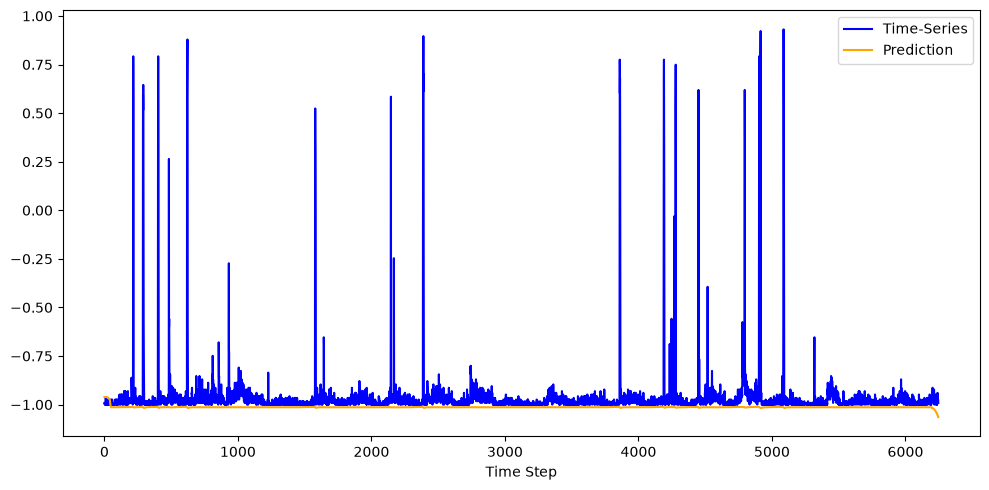

------------------
Twitter Metrics
------------------
[point] Precision: 0.119 | Recall: 0.600 | F1: 0.194
[area] Precision: 0.127 | Recall: 0.650 | F1: 0.207


In [29]:
total_metrics = {name: np.zeros(3) for (name, _) in NAB_HYPERPARAMS["rec_error_funcs"]}

for i, twitter_signal in enumerate(twitter_signals):
    X = twitter_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = twitter_signal['is_anomaly'].to_numpy()

    print("--------------")
    print(f"Twitter Signal {i + 1}")
    print("--------------")
    
    metrics = run_pipeline(X, y, **NAB_HYPERPARAMS)

    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])

print("------------------")
print("Twitter Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / len(twitter_signals)
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")